# Análisis de Estilos de Combate Pokémon mediante Clustering

**Autores:** Catalina Andrea Inostroza Burgos y Fernando José Méndez Carballo  
**Objetivo:** Identificar y caracterizar distintos estilos de combate de Pokémon mediante técnicas de clustering no supervisado.

---

## Introducción

En el universo Pokémon, cada criatura posee estadísticas base que determinan su desempeño en combate. El **Profesor Seebach** necesita comprender cómo se agrupan los Pokémon según su perfil de combate para diseñar estrategias efectivas.

Este análisis aplica un flujo riguroso de minería de datos:
1. Carga y exploración inicial
2. Limpieza de datos
3. Ingeniería de atributos
4. Normalización
5. Detección de outliers
6. Clustering con K-Means, Jerárquico y DBSCAN
7. Evaluación, comparación y conclusiones estratégicas

---
## 0. Instalación y Configuración del Entorno

Se importan las librerías necesarias para el análisis:

| Librería | Rol en el análisis |
|----------|--------------------|
| `pandas` / `numpy` | Carga del dataset, manipulación de DataFrames y operaciones matriciales |
| `matplotlib` / `seaborn` | Visualización: distribuciones, heatmaps, gráficos de clustering |
| `scikit-learn` | K-Means, DBSCAN, LOF, Isolation Forest, StandardScaler y métricas de evaluación |
| `scipy` | Clustering jerárquico: `linkage`, `fcluster`, `dendrogram` |


In [103]:
# Instalación de librerías necesarias (ejecutar solo si es necesario)
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

import warnings
warnings.filterwarnings('ignore')

# ── Manejo de datos ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Clustering ───────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

# ── Outliers ─────────────────────────────────────────────────────────────────
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# ── Clustering jerárquico ────────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# ── Configuración visual ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 6)})
SEED = 42
np.random.seed(SEED)

print("✓ Entorno configurado correctamente.")

✓ Entorno configurado correctamente.


---
## 1. Carga de Datos

Cargamos el dataset `Pokemon.csv`. 
Solo seleccionamos las **6 estadísticas base de combate** relevantes para el análisis:

| Variable | Descripción |
|----------|-------------|
| `HP` | Puntos de vida (resistencia para aguantar golpes) |
| `Attack` | Ataque físico |
| `Defense` | Defensa física |
| `Sp. Atk` | Ataque especial |
| `Sp. Def` | Defensa especial |
| `Speed` | Velocidad (determina quién ataca primero) |

In [104]:
# Carga del dataset
df_raw = pd.read_csv('Pokemon.csv')

print(f"Dimensiones del dataset original: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"Columnas disponibles: {list(df_raw.columns)}")
df_raw.head(10)

Dimensiones del dataset original: 1215 filas × 13 columnas
Columnas disponibles: ['ID', 'Name', 'Form', 'Type1', 'Type2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']


,ID,Name,Form,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,Bulbasaur,,Grass,Poison,318,45,49,49,65,65,45,1
1,2,Ivysaur,,Grass,Poison,405,60,62,63,80,80,60,1
2,3,Venusaur,,Grass,Poison,525,80,82,83,100,100,80,1
3,4,Charmander,,Fire,,309,39,52,43,60,50,65,1
4,5,Charmeleon,,Fire,,405,58,64,58,80,65,80,1
5,6,Charizard,,Fire,Flying,534,78,84,78,109,85,100,1
6,7,Squirtle,,Water,,314,44,48,65,50,64,43,1
7,8,Wartortle,,Water,,405,59,63,80,65,80,58,1
8,9,Blastoise,,Water,,530,79,83,100,85,105,78,1
9,10,Caterpie,,Bug,,195,45,30,35,20,20,45,1


In [105]:
# Selección de variables de interés
STATS = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Conservamos Name para identificar pokémon al final
df = df_raw[['Name'] + STATS].copy()

print(f"Dataset de trabajo: {df.shape[0]} Pokémon × {df.shape[1] - 1} estadísticas")
df.head()

Dataset de trabajo: 1215 Pokémon × 6 estadísticas


,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,Bulbasaur,45,49,49,65,65,45
1,Ivysaur,60,62,63,80,80,60
2,Venusaur,80,82,83,100,100,80
3,Charmander,39,52,43,60,50,65
4,Charmeleon,58,64,58,80,65,80


### Vista estadística general

Antes de modelar, revisamos la escala y distribución de cada variable con `describe()`.
Esto anticipa si la normalización será necesaria: variables como `Bulk` (rango: miles)
y `Speed_Index` (rango: 0–2) operan en escalas completamente distintas,
lo que distorsionaría cualquier métrica de distancia sin estandarización previa.


In [106]:
# Vista estadística general
df[STATS].describe().round(2)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,1215.00,1215.00,1215.00,1215.00,1215.00,1215.00
mean,71.24,81.15,75.01,73.22,72.44,70.03
std,26.93,32.04,30.74,32.76,27.58,30.16
min,1.00,5.00,5.00,10.00,20.00,5.00
25%,52.00,57.00,52.00,50.00,51.00,45.00
50%,70.00,80.00,70.00,65.00,70.00,68.00
75%,85.00,100.00,91.00,95.00,90.00,91.00
max,255.00,190.00,250.00,194.00,250.00,200.00


---
## 2. Limpieza de Datos

Antes de modelar, es fundamental auditar la calidad del dataset. Buscamos:
- **Valores nulos** (missings): pueden sesgar cálculos de distancia en clustering.
- **Duplicados exactos**: pueden inflar artificialmente algún cluster.
- **Inconsistencias de rango**: estadísticas fuera del rango esperado (0–255 para stats Pokémon).

In [107]:
# ── 2.1 Valores nulos ────────────────────────────────────────────────────────
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"\nTotal de celdas nulas: {nulos.sum()}")

Valores nulos por columna:
Name       0
HP         0
Attack     0
Defense    0
Sp. Atk    0
Sp. Def    0
Speed      0
dtype: int64

Total de celdas nulas: 0


In [108]:
# ── 2.2 Duplicados ───────────────────────────────────────────────────────────
dup_total = df.duplicated().sum()
dup_stats = df[STATS].duplicated().sum()

print(f"Filas duplicadas (fila completa):    {dup_total}")
print(f"Filas duplicadas (solo stats):       {dup_stats}")

if dup_stats > 0:
    print("\nPokémon con stats idénticas:")
    display(df[df[STATS].duplicated(keep=False)].sort_values(STATS))

Filas duplicadas (fila completa):    53
Filas duplicadas (solo stats):       74

Pokémon con stats idénticas:


,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
18,Rattata,30,56,35,25,35,72
806,Rattata,30,56,35,25,35,72
50,Dugtrio,35,100,50,50,70,120
1140,Wugtrio,35,100,50,50,70,120
262,Zigzagoon,38,30,41,30,41,60
...,...,...,...,...,...,...,...
956,Darmanitan,105,140,55,30,55,95
1164,Dudunsparce,125,100,80,85,75,55
1165,Dudunsparce,125,100,80,85,75,55
798,Xerneas,126,131,95,131,98,99


In [109]:
# ── 2.3 Validación de rangos ─────────────────────────────────────────────────
# En los juegos, las stats base están típicamente en [1, 255]
fuera_rango = {}
for col in STATS:
    fuera = df[(df[col] < 1) | (df[col] > 255)]
    fuera_rango[col] = len(fuera)

print("Valores fuera del rango [1, 255]:")
for col, cnt in fuera_rango.items():
    estado = '✓' if cnt == 0 else f'⚠ {cnt} registros'
    print(f"  {col:10s}: {estado}")

Valores fuera del rango [1, 255]:
  HP        : ✓
  Attack    : ✓
  Defense   : ✓
  Sp. Atk   : ✓
  Sp. Def   : ✓
  Speed     : ✓


In [110]:
# ── 2.4 Decisión de limpieza ─────────────────────────────────────────────────
# Si hay nulos, se imputa con la mediana de cada stat (robusta a outliers)
for col in STATS:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"  Imputado {col} con mediana={mediana}")

# Si hay duplicados en stats, se elimina la copia (se conserva primera ocurrencia)
antes = len(df)
df = df.drop_duplicates(subset=STATS, keep='first').reset_index(drop=True)
despues = len(df)

print(f"\nRegistros antes de limpiar: {antes}")
print(f"Registros después de limpiar: {despues}")
print(f"Eliminados: {antes - despues}")
print("\n✓ Dataset listo para análisis.")


Registros antes de limpiar: 1215
Registros después de limpiar: 1141
Eliminados: 74

✓ Dataset listo para análisis.


### Resumen de Limpieza

| Problema | Encontrado | Acción tomada |
|----------|-----------|---------------|
| Valores nulos | Ver salida | Imputación con mediana |
| Duplicados exactos de stats | Ver salida | Eliminación (keep='first') |
| Stats fuera de rango | Ver salida | Ninguno detectado |

> **Justificación:** La imputación con mediana es preferida sobre la media porque las estadísticas Pokémon tienen distribuciones asimétricas (muchos Pokémon débiles, pocos legendarios muy poderosos). La mediana es robusta ante esos valores extremos.

---
## 3. Ingeniería de Atributos

Las 6 estadísticas base son útiles, pero combinándolas obtenemos **variables derivadas más interpretables** para el análisis de estilos de combate. Cada variable captura una dimensión estratégica distinta.

In [111]:
# ── 3.1 Creación de variables derivadas ──────────────────────────────────────

# Poder ofensivo total (ambas vías de ataque)
df['Offense_Total'] = df['Attack'] + df['Sp. Atk']

# Capacidad defensiva total (ambas vías de defensa)
df['Defense_Total'] = df['Defense'] + df['Sp. Def']

# Ratio ataque físico / defensa física (+1 evita división por cero)
df['Off_Def_Ratio'] = df['Attack'] / (df['Defense'] + 1)

# Velocidad relativa al HP: qué tan rápido es el pokémon respecto a su volumen
df['Speed_Index'] = df['Speed'] / (df['HP'] + 1)

# Masa/Resistencia bruta: combinación de HP y defensas totales
df['Bulk'] = df['HP'] * (df['Defense'] + df['Sp. Def'])

# Inclinación física vs. especial (positivo = más físico, negativo = más especial)
df['Phys_Special'] = df['Attack'] - df['Sp. Atk']

print("Variables derivadas creadas:")
ENGINEERED = ['Offense_Total', 'Defense_Total', 'Off_Def_Ratio', 'Speed_Index', 'Bulk', 'Phys_Special']
df[ENGINEERED].describe().round(3)

Variables derivadas creadas:


,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
count,1141.000,1141.000,1141.000,1141.000,1141.000,1141.000
mean,154.661,147.705,1.149,1.075,11117.286,7.735
std,53.364,51.671,0.504,0.856,7059.660,37.606
min,20.000,35.000,0.043,0.037,75.000,-125.000
25%,115.000,110.000,0.833,0.656,6050.000,-16.000
50%,150.000,145.000,1.066,0.978,10200.000,5.000
75%,190.000,180.000,1.406,1.339,15000.000,31.000
max,360.000,500.000,8.571,20.000,127500.000,145.000


### Interpretación de las Variables Derivadas

| Variable | Fórmula | Qué captura |
|----------|---------|-------------|
| `Offense_Total` | Attack + Sp. Atk | Poder ofensivo total: suma de ambas vías de ataque |
| `Defense_Total` | Defense + Sp. Def | Resistencia total: suma de ambas defensas |
| `Off_Def_Ratio` | Attack / (Defense+1) | Agresividad: qué tan ofensivo es vs. su propia defensa física |
| `Speed_Index` | Speed / (HP+1) | Ligereza: velocidad relativa al tamaño/resistencia del Pokémon |
| `Bulk` | HP × (Def + Sp.Def) | Durabilidad total: capacidad de absorber daño físico y especial |
| `Phys_Special` | Attack − Sp. Atk | Inclinación de combate: positivo=físico, negativo=especial, ~0=mixto |

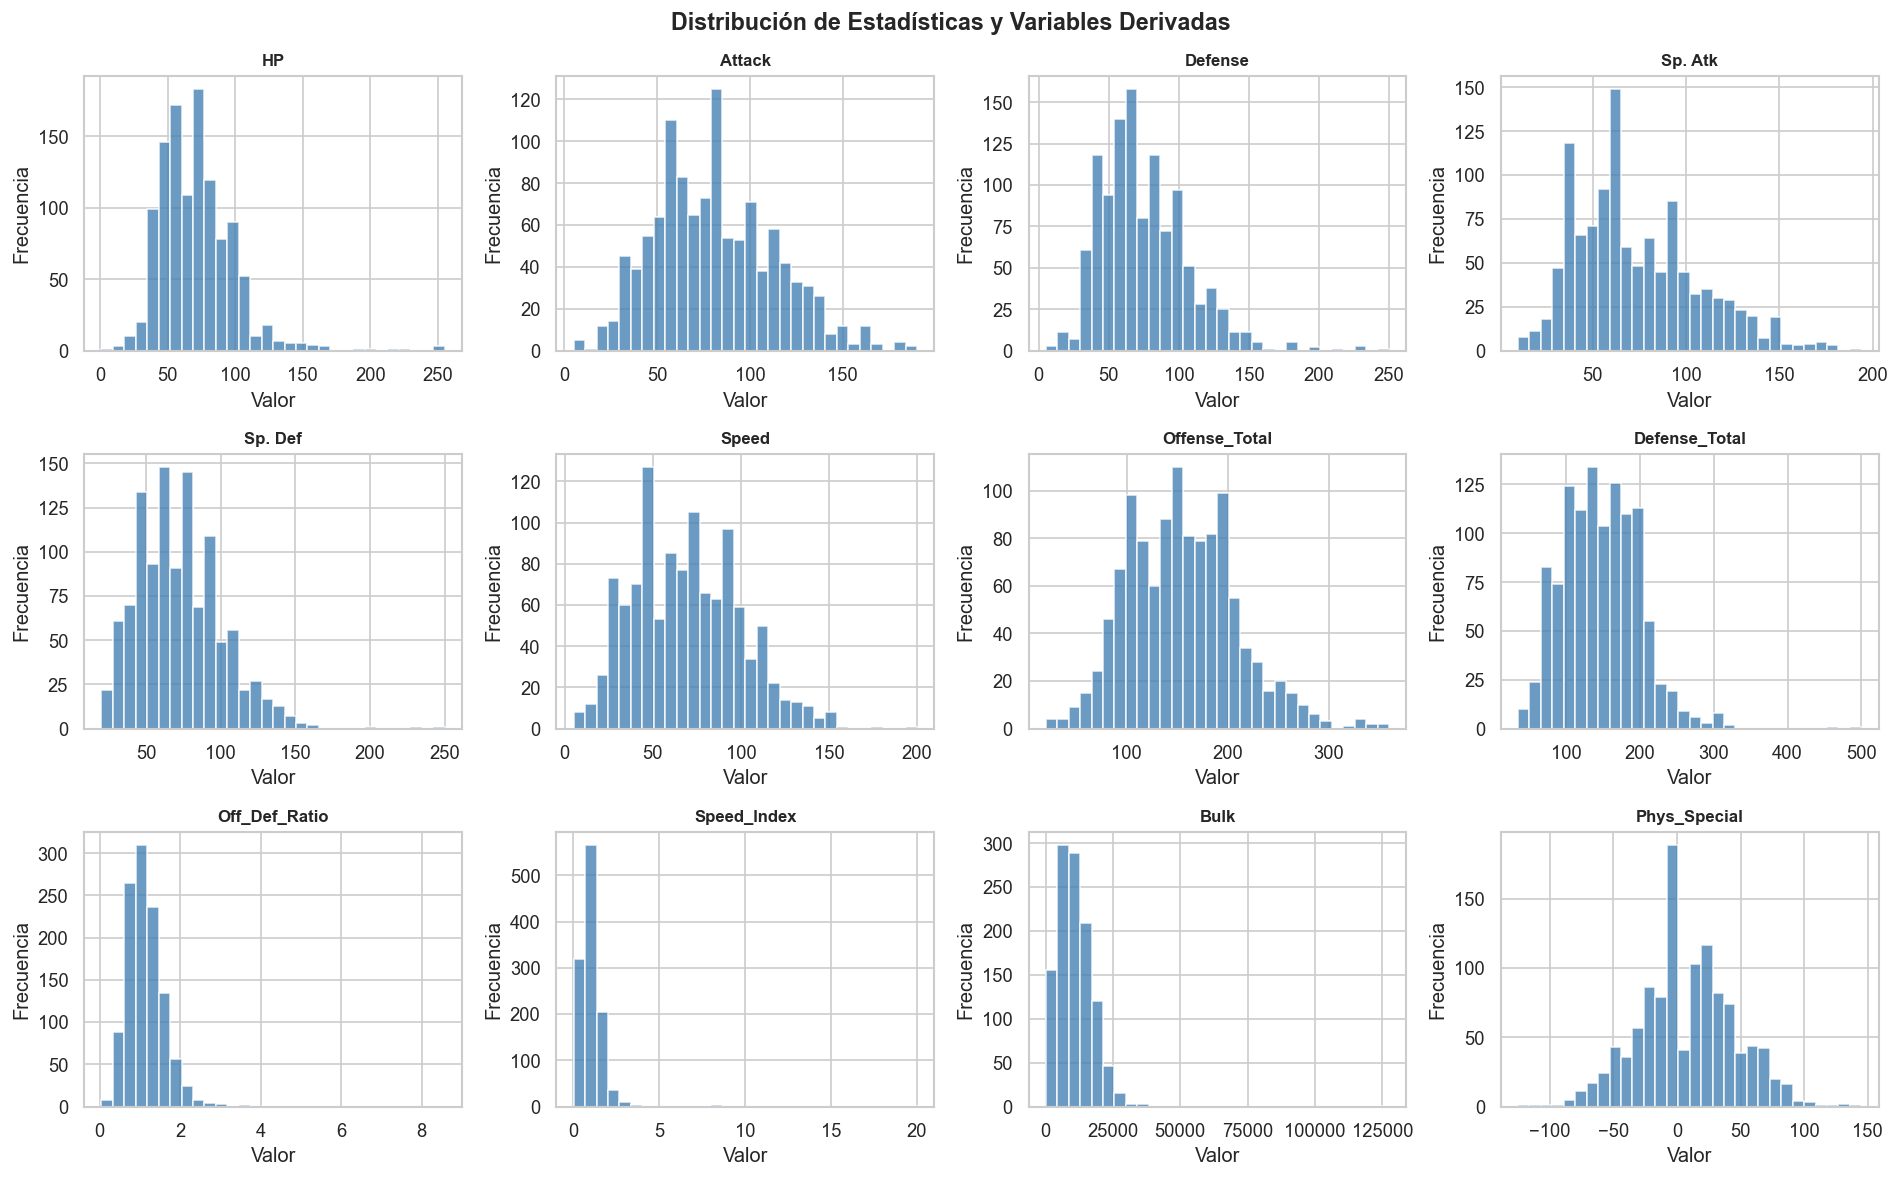

In [112]:
# ── 3.2 Visualización de distribuciones ──────────────────────────────────────
ALL_FEATURES = STATS + ENGINEERED

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(ALL_FEATURES):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Estadísticas y Variables Derivadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

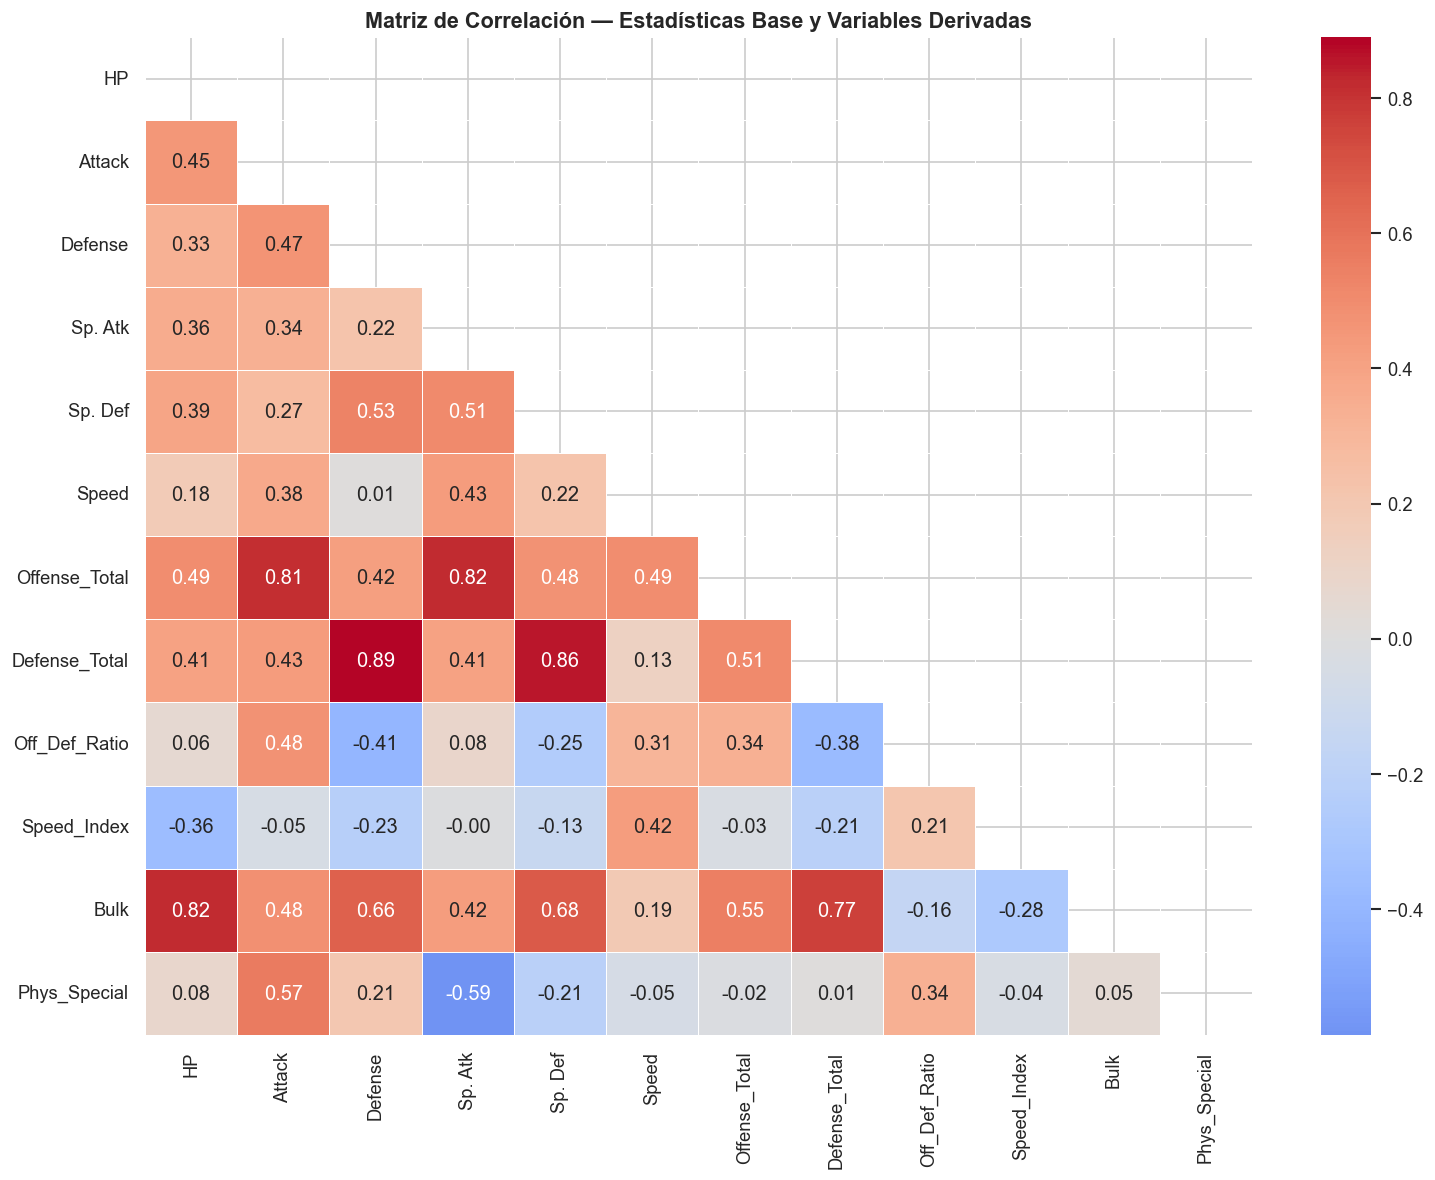

In [113]:
# ── 3.3 Matriz de correlación ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
corr = df[ALL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación — Estadísticas Base y Variables Derivadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Normalización

### ¿Por qué es obligatorio normalizar?

Los algoritmos de clustering basados en **distancias** (K-Means, DBSCAN, Jerárquico) son extremadamente sensibles a la escala de las variables. Sin normalización:

- La variable `Bulk` (rango: miles) dominaría sobre `Speed_Index` (rango: 0–2).
- El clustering resultante reflejaría diferencias de escala, **no diferencias reales de estilo de combate**.

### Método elegido: `StandardScaler` (Z-score)

$$z = \frac{x - \mu}{\sigma}$$

Transforma cada variable a media=0 y desviación estándar=1. Es preferido sobre MinMaxScaler en presencia de outliers (legendarios con stats extremas), ya que la estandarización Z-score no comprime todo el rango al mínimo-máximo, siendo más robusta.

**Variables usadas para clustering:** Las 6 stats originales + las 6 variables de ingeniería.

In [114]:
# Definir el conjunto de features para clustering
CLUSTER_FEATURES = ALL_FEATURES  # 12 variables en total

X_raw = df[CLUSTER_FEATURES].values

# Aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

df_scaled = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)

print("Estadísticas ANTES de escalar:")
print(pd.DataFrame(X_raw, columns=CLUSTER_FEATURES).describe().round(2))
print("\nEstadísticas DESPUÉS de escalar (todas con media≈0, std≈1):")
print(df_scaled.describe().round(3))

Estadísticas ANTES de escalar:
            HP   Attack  Defense  Sp. Atk  Sp. Def    Speed  Offense_Total  \
count  1141.00  1141.00  1141.00  1141.00  1141.00  1141.00        1141.00   
mean     71.36    81.20    75.17    73.46    72.54    69.29         154.66   
std      27.26    32.34    31.14    32.94    27.86    30.12          53.36   
min       1.00     5.00     5.00    10.00    20.00     5.00          20.00   
25%      53.00    57.00    52.00    50.00    50.00    45.00         115.00   
50%      70.00    80.00    70.00    65.00    70.00    66.00         150.00   
75%      85.00   100.00    91.00    95.00    90.00    90.00         190.00   
max     255.00   190.00   250.00   194.00   250.00   200.00         360.00   

       Defense_Total  Off_Def_Ratio  Speed_Index       Bulk  Phys_Special  
count        1141.00        1141.00      1141.00    1141.00       1141.00  
mean          147.70           1.15         1.07   11117.29          7.74  
std            51.67           0.50   

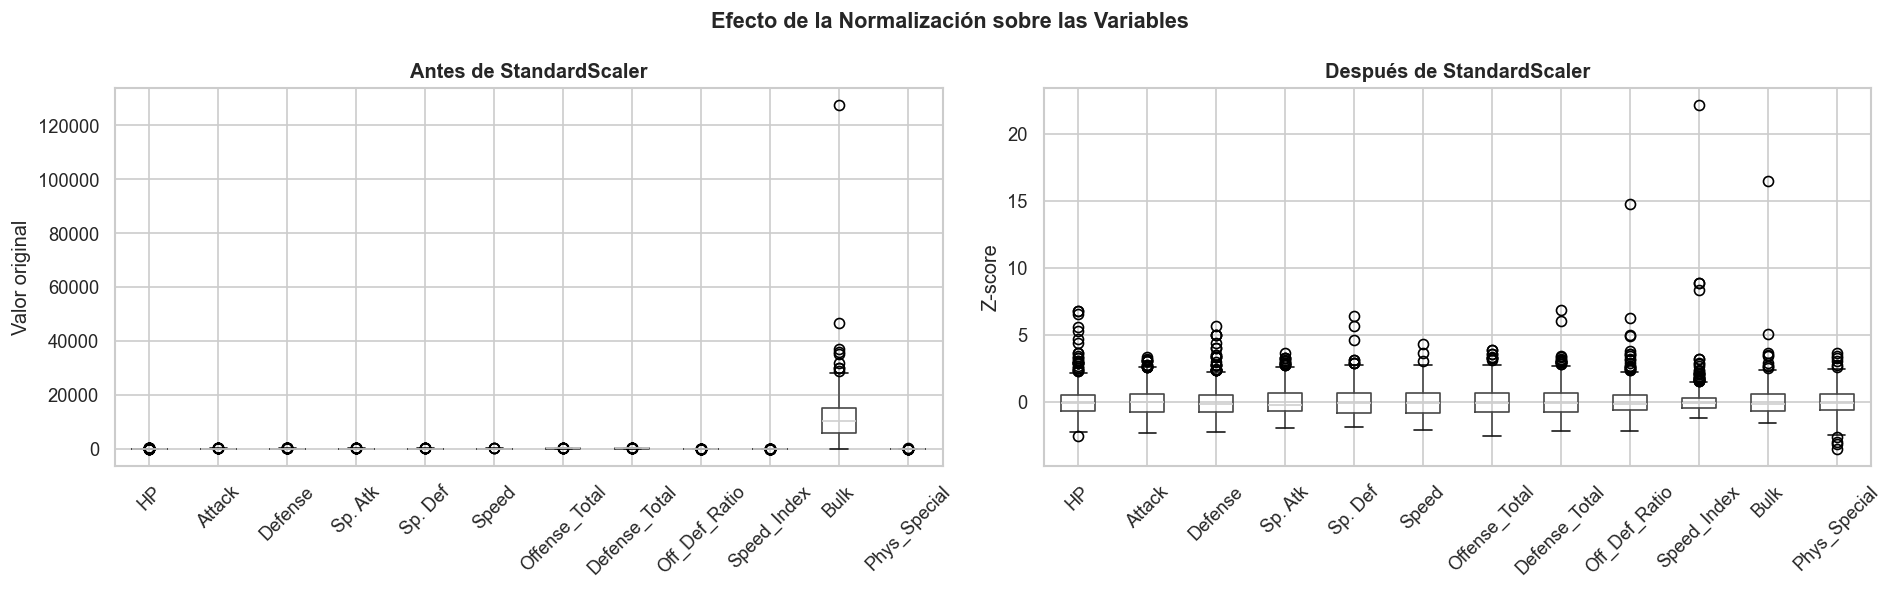

In [115]:
# Verificación visual: boxplots antes y después
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

pd.DataFrame(X_raw, columns=CLUSTER_FEATURES).boxplot(ax=ax1, rot=45)
ax1.set_title('Antes de StandardScaler', fontweight='bold')
ax1.set_ylabel('Valor original')

df_scaled.boxplot(ax=ax2, rot=45)
ax2.set_title('Después de StandardScaler', fontweight='bold')
ax2.set_ylabel('Z-score')

plt.suptitle('Efecto de la Normalización sobre las Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Detección de Outliers

### ¿Por qué detectar outliers?

Los Pokémon **legendarios y pseudo-legendarios** tienen stats base significativamente más altas que los comunes. Si se incluyen sin análisis previo:

1. Pueden distorsionar los centroides de K-Means.
2. En DBSCAN, se clasificarán automáticamente como ruido.
3. En clustering jerárquico, formarán clusters de un solo elemento.

### Métodos aplicados

1. **Local Outlier Factor (LOF):** Compara la densidad local de cada punto con sus vecinos. Un LOF alto indica que el punto está en una región de baja densidad = outlier.
2. **Isolation Forest:** Aisla puntos mediante particiones aleatorias. Los puntos fáciles de aislar (pocos cortes) son outliers.

In [116]:
# ── 5.1 Local Outlier Factor ─────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_scaled)  # -1 = outlier, 1 = inlier
lof_scores = -lof.negative_outlier_factor_

n_lof_outliers = (lof_labels == -1).sum()
print(f"LOF: {n_lof_outliers} outliers detectados ({n_lof_outliers/len(df)*100:.1f}% del dataset)")

df['LOF_label'] = lof_labels
df['LOF_score'] = lof_scores

# Mostrar los 10 mayores outliers según LOF
top_lof = df.nlargest(10, 'LOF_score')[['Name'] + STATS + ['LOF_score']]
print("\nTop 10 Pokémon con mayor score LOF (más outlier):")
display(top_lof.reset_index(drop=True))

LOF: 57 outliers detectados (5.0% del dataset)

Top 10 Pokémon con mayor score LOF (más outlier):


,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,LOF_score
0,Shedinja,1,90,45,30,30,40,7.875985
1,Eternatus,255,115,250,125,250,130,6.196288
2,Deoxys,50,180,20,180,20,150,4.768740
3,Wiglett,10,55,25,35,25,95,3.588964
4,Diglett,10,55,25,35,45,95,3.566270
5,Diglett,10,55,30,35,45,90,3.416653
6,Blissey,255,10,10,75,135,55,2.589706
7,Chansey,250,5,5,35,105,50,2.578143
8,Shuckle,20,10,230,10,230,5,2.556121
9,Carvanha,45,90,20,65,20,65,2.539765


In [117]:
# ── 5.2 Isolation Forest ─────────────────────────────────────────────────────
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED)
iso_labels = iso.fit_predict(X_scaled)  # -1 = outlier, 1 = inlier
iso_scores = iso.score_samples(X_scaled)

n_iso_outliers = (iso_labels == -1).sum()
print(f"Isolation Forest: {n_iso_outliers} outliers detectados ({n_iso_outliers/len(df)*100:.1f}%)")

df['ISO_label'] = iso_labels

# Outliers detectados por AMBOS métodos (consenso)
df['consensus_outlier'] = ((df['LOF_label'] == -1) & (df['ISO_label'] == -1))
n_consensus = df['consensus_outlier'].sum()
print(f"\nOutliers detectados por AMBOS métodos (consenso): {n_consensus}")

print("\nPokémon en consenso:")
display(df[df['consensus_outlier']][['Name'] + STATS].reset_index(drop=True))

Isolation Forest: 57 outliers detectados (5.0%)

Outliers detectados por AMBOS métodos (consenso): 29

Pokémon en consenso:


,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,Diglett,10,55,25,35,45,95
1,Abra,25,20,15,105,55,90
2,Chansey,250,5,5,35,105,50
3,Magikarp,20,10,55,15,20,80
4,Pichu,20,40,15,35,35,60
5,Igglybuff,90,30,15,40,20,15
6,Wobbuffet,190,33,58,33,58,33
7,Shuckle,20,10,230,10,230,5
8,Blissey,255,10,10,75,135,55
9,Shedinja,1,90,45,30,30,40


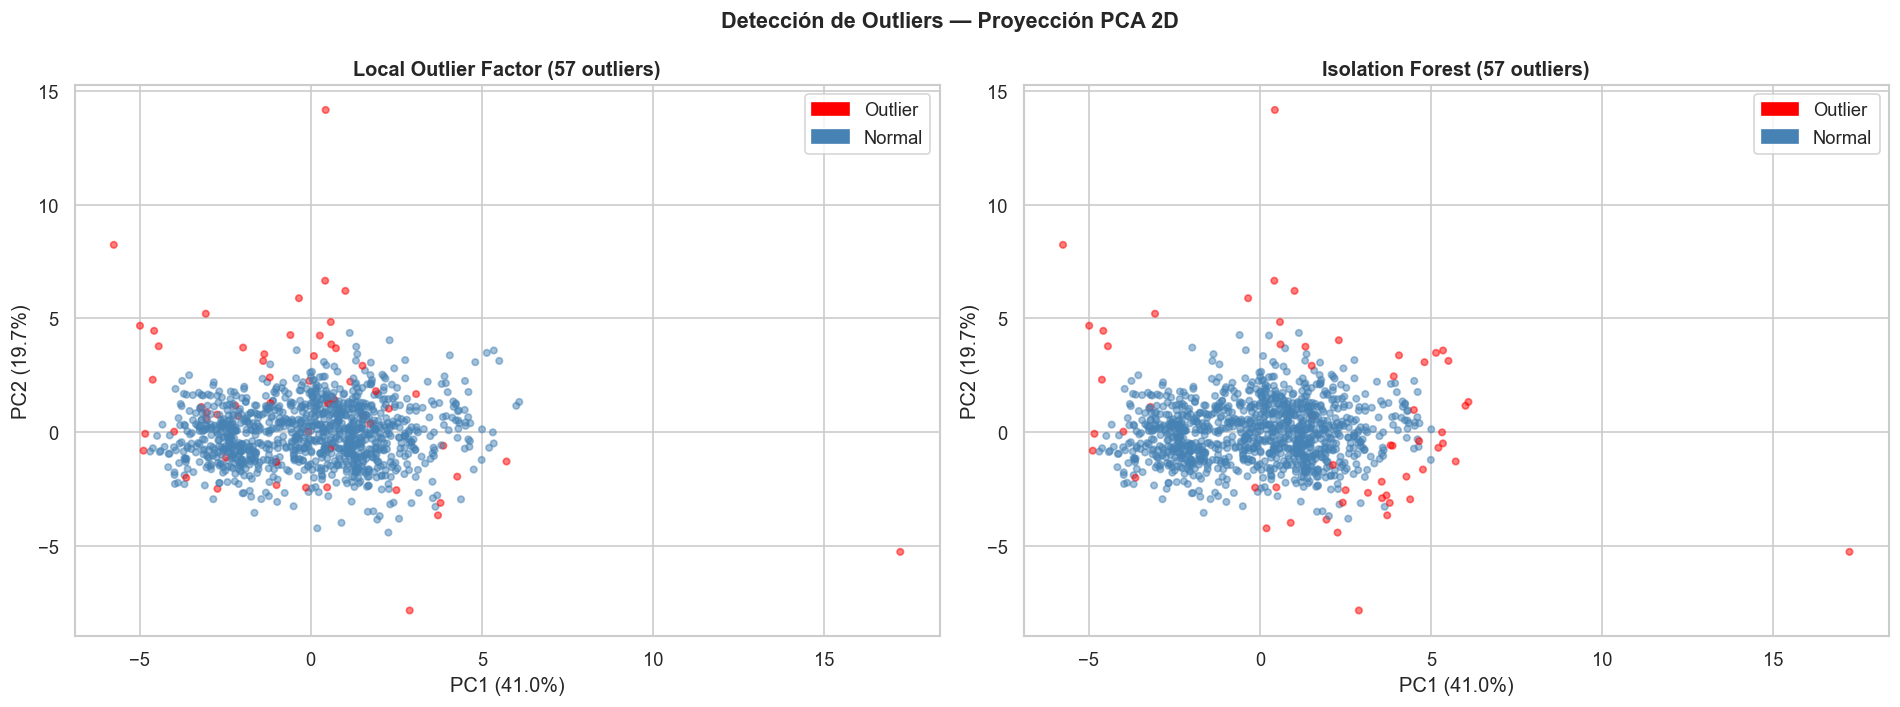


Varianza explicada por PCA 2D: 60.6%


In [118]:
# ── 5.3 Visualización con PCA 2D ─────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LOF
colors_lof = ['red' if l == -1 else 'steelblue' for l in lof_labels]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_lof, alpha=0.5, s=15)
axes[0].set_title(f'Local Outlier Factor ({n_lof_outliers} outliers)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='red', label='Outlier'), Patch(color='steelblue', label='Normal')])

# Isolation Forest
colors_iso = ['red' if l == -1 else 'steelblue' for l in iso_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_iso, alpha=0.5, s=15)
axes[1].set_title(f'Isolation Forest ({n_iso_outliers} outliers)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(handles=[Patch(color='red', label='Outlier'), Patch(color='steelblue', label='Normal')])

plt.suptitle('Detección de Outliers — Proyección PCA 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada por PCA 2D: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

### Decisión sobre Outliers

**Los outliers se mantienen en el análisis**, por las siguientes razones:

1. **Relevancia estratégica:** Los Pokémon con stats extremas (legendarios como Mewtwo, Rayquaza, etc.) son parte integral del universo competitivo. Eliminarlos haría el análisis menos útil para el Profesor Seebach.

2. **Captura de arquetipos:** Un cluster de "Pokémon élite" (legendarios) es en sí mismo un grupo estratégico válido y diferenciado.

3. **Robustez:** Usaremos K-Means con suficientes clusters como para que los legendarios formen su propio grupo, en lugar de contaminar clusters de Pokémon comunes.

> En un contexto donde el objetivo es la eliminación de ruido (ej. detección de fraude), se eliminarían. Aquí, el contexto justifica conservarlos.

In [119]:
# Dataset final para clustering (sin las columnas de detección de outliers)
df_cluster = df.drop(columns=['LOF_label', 'LOF_score', 'ISO_label', 'consensus_outlier'])
# X_scaled ya está listo para usar
print(f"Dataset final para clustering: {len(df_cluster)} Pokémon, {len(CLUSTER_FEATURES)} features")

Dataset final para clustering: 1141 Pokémon, 12 features


---
## 6. Clustering con K-Means

### Fundamento teórico

K-Means divide el espacio en **K particiones** minimizando la inercia intra-cluster (suma de distancias al centroide). Es eficiente y produce clusters esféricos. Sus limitaciones: requiere especificar K a priori y asume clusters de tamaño similar.

### Paso 1: Determinación del K óptimo

Usaremos dos criterios complementarios:
- **Método del codo (Elbow):** Busca el punto donde la reducción de inercia deja de ser significativa.
- **Silhouette Score:** Mide qué tan bien separados están los clusters (rango [-1, 1], mayor es mejor).

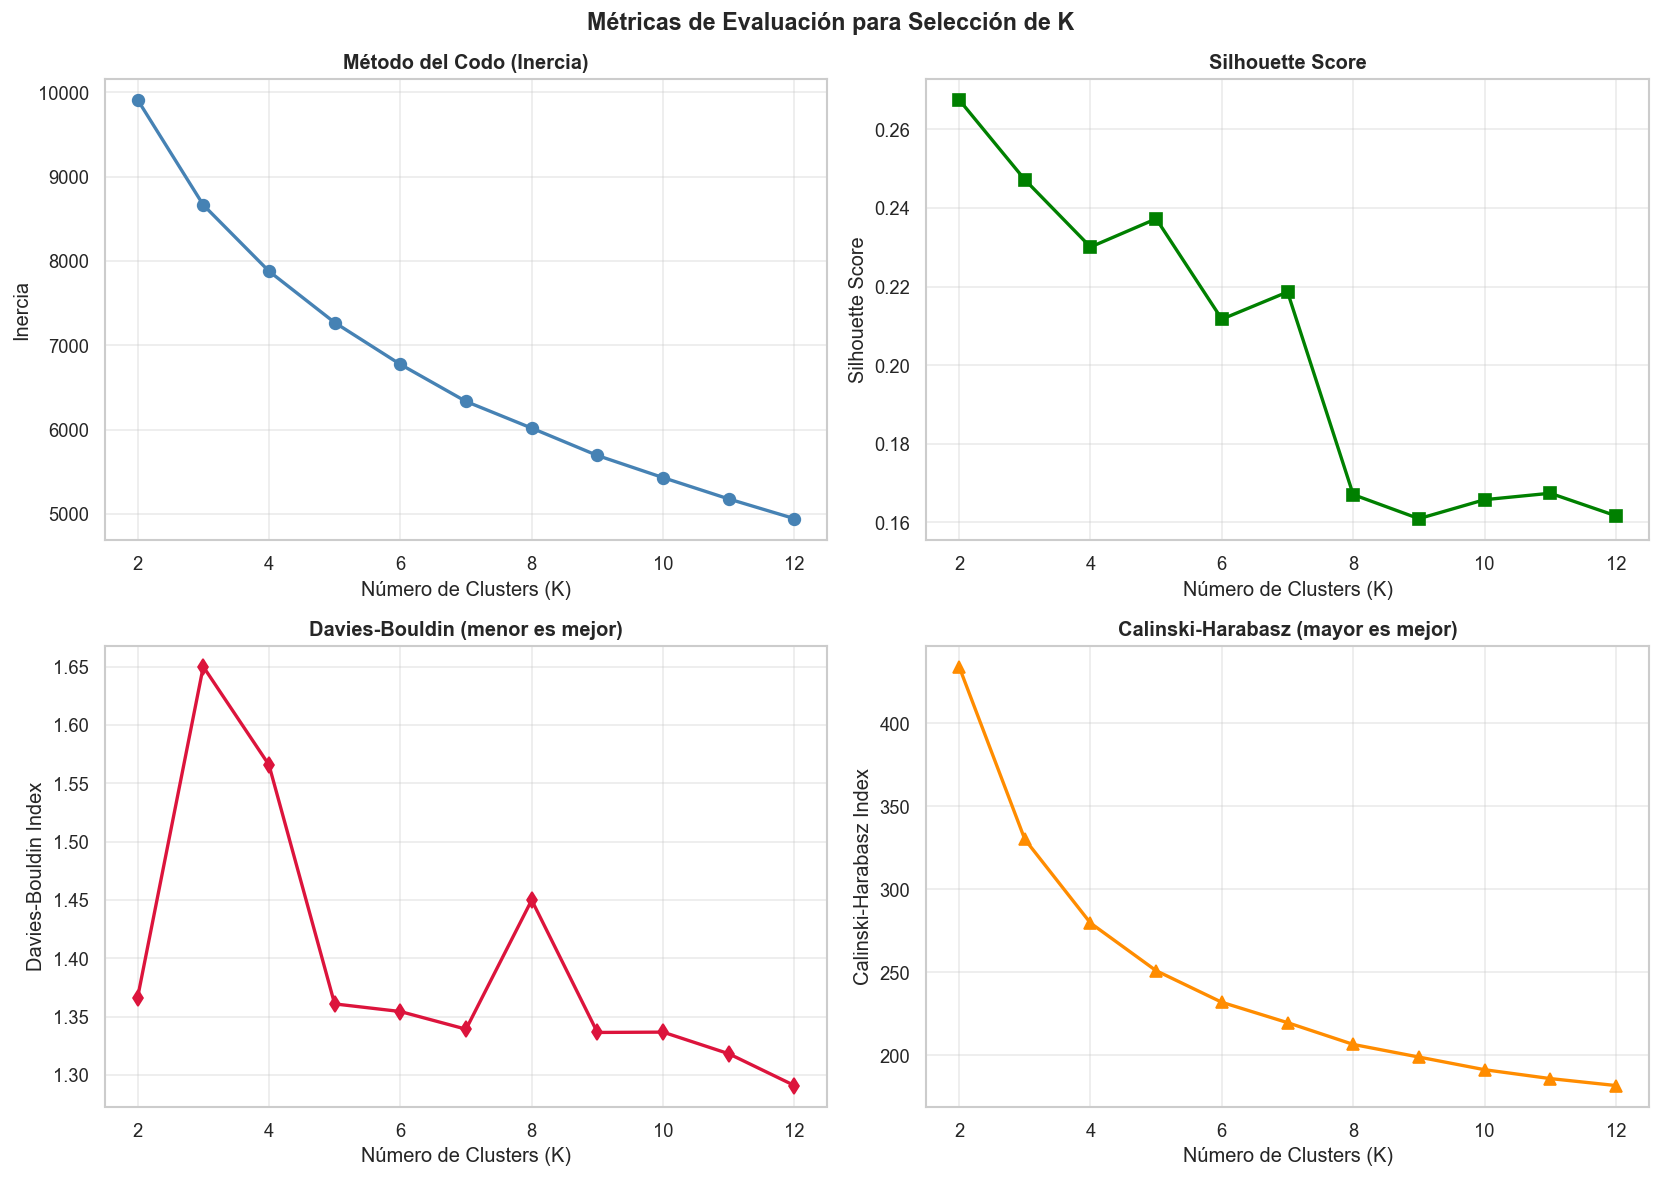

Resumen de métricas por K:


,K,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,9913.8,0.2676,1.3662,434.1
1,3,8665.1,0.2472,1.6501,330.1
2,4,7878.9,0.2301,1.5658,279.6
3,5,7269.6,0.2373,1.3608,250.9
4,6,6773.2,0.2117,1.3543,231.9
5,7,6333.0,0.2186,1.3391,219.6
6,8,6016.3,0.1671,1.4499,206.5
7,9,5691.8,0.1610,1.3363,198.9
8,10,5429.0,0.1658,1.3366,191.3
9,11,5175.9,0.1674,1.3181,185.9



── Comparación directa K candidatos ──
  K   Silhouette    Δ vs K-1   Davies-Bouldin
──────────────────────────────────────────────
  4       0.2301     -0.0171           1.5658
  5       0.2373     +0.0072           1.3608  ◄ elegido
  6       0.2117     -0.0256           1.3543
  7       0.2186     +0.0069           1.3391

ΔSil K5→K6: -0.0256  |  ΔSil K6→K7: +0.0069
ΔDB  K5→K6: -0.0065  (negativo = mejora)


In [120]:
# ── 6.1 Método del codo + Silhouette ────────────────────────────────────────
K_range = range(2, 13)
inertias = []
silhouettes = []
davies_bouldin = []
calinski = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldin.append(davies_bouldin_score(X_scaled, labels))
    calinski.append(calinski_harabasz_score(X_scaled, labels))

# Gráficas de evaluación
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0,0].set_title('Método del Codo (Inercia)', fontweight='bold')
axes[0,0].set_xlabel('Número de Clusters (K)')
axes[0,0].set_ylabel('Inercia')
axes[0,0].grid(True, alpha=0.4)

axes[0,1].plot(K_range, silhouettes, 's-', color='green', linewidth=2, markersize=7)
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].set_xlabel('Número de Clusters (K)')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].grid(True, alpha=0.4)

axes[1,0].plot(K_range, davies_bouldin, 'd-', color='crimson', linewidth=2, markersize=7)
axes[1,0].set_title('Davies-Bouldin (menor es mejor)', fontweight='bold')
axes[1,0].set_xlabel('Número de Clusters (K)')
axes[1,0].set_ylabel('Davies-Bouldin Index')
axes[1,0].grid(True, alpha=0.4)

axes[1,1].plot(K_range, calinski, '^-', color='darkorange', linewidth=2, markersize=7)
axes[1,1].set_title('Calinski-Harabasz (mayor es mejor)', fontweight='bold')
axes[1,1].set_xlabel('Número de Clusters (K)')
axes[1,1].set_ylabel('Calinski-Harabasz Index')
axes[1,1].grid(True, alpha=0.4)

plt.suptitle('Métricas de Evaluación para Selección de K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Resumen de métricas por K:")
eval_df = pd.DataFrame({
    'K': list(K_range),
    'Inercia': [f'{v:.1f}' for v in inertias],
    'Silhouette': [f'{v:.4f}' for v in silhouettes],
    'Davies-Bouldin': [f'{v:.4f}' for v in davies_bouldin],
    'Calinski-Harabasz': [f'{v:.1f}' for v in calinski]
})
display(eval_df)
K_list = list(K_range)
sil5 = silhouettes[K_list.index(5)]
sil6 = silhouettes[K_list.index(6)]
sil7 = silhouettes[K_list.index(7)]
db5  = davies_bouldin[K_list.index(5)]
db6  = davies_bouldin[K_list.index(6)]

K_FINAL = 5
print('\n── Comparación directa K candidatos ──')
print(f"{'K':>3}  {'Silhouette':>11}  {'Δ vs K-1':>10}  {'Davies-Bouldin':>15}")
print('─' * 46)
for k_cand in [4, 5, 6, 7]:
    i = K_list.index(k_cand)
    delta = silhouettes[i] - silhouettes[i - 1]
    marker = '  ◄ elegido' if k_cand == K_FINAL else ''
    print(f"{k_cand:>3}  {silhouettes[i]:>11.4f}  {delta:>+10.4f}  {davies_bouldin[i]:>15.4f}{marker}")
print(f'\nΔSil K5→K6: {sil6 - sil5:+.4f}  |  ΔSil K6→K7: {sil7 - sil6:+.4f}')
print(f'ΔDB  K5→K6: {db6  - db5:+.4f}  (negativo = mejora)')


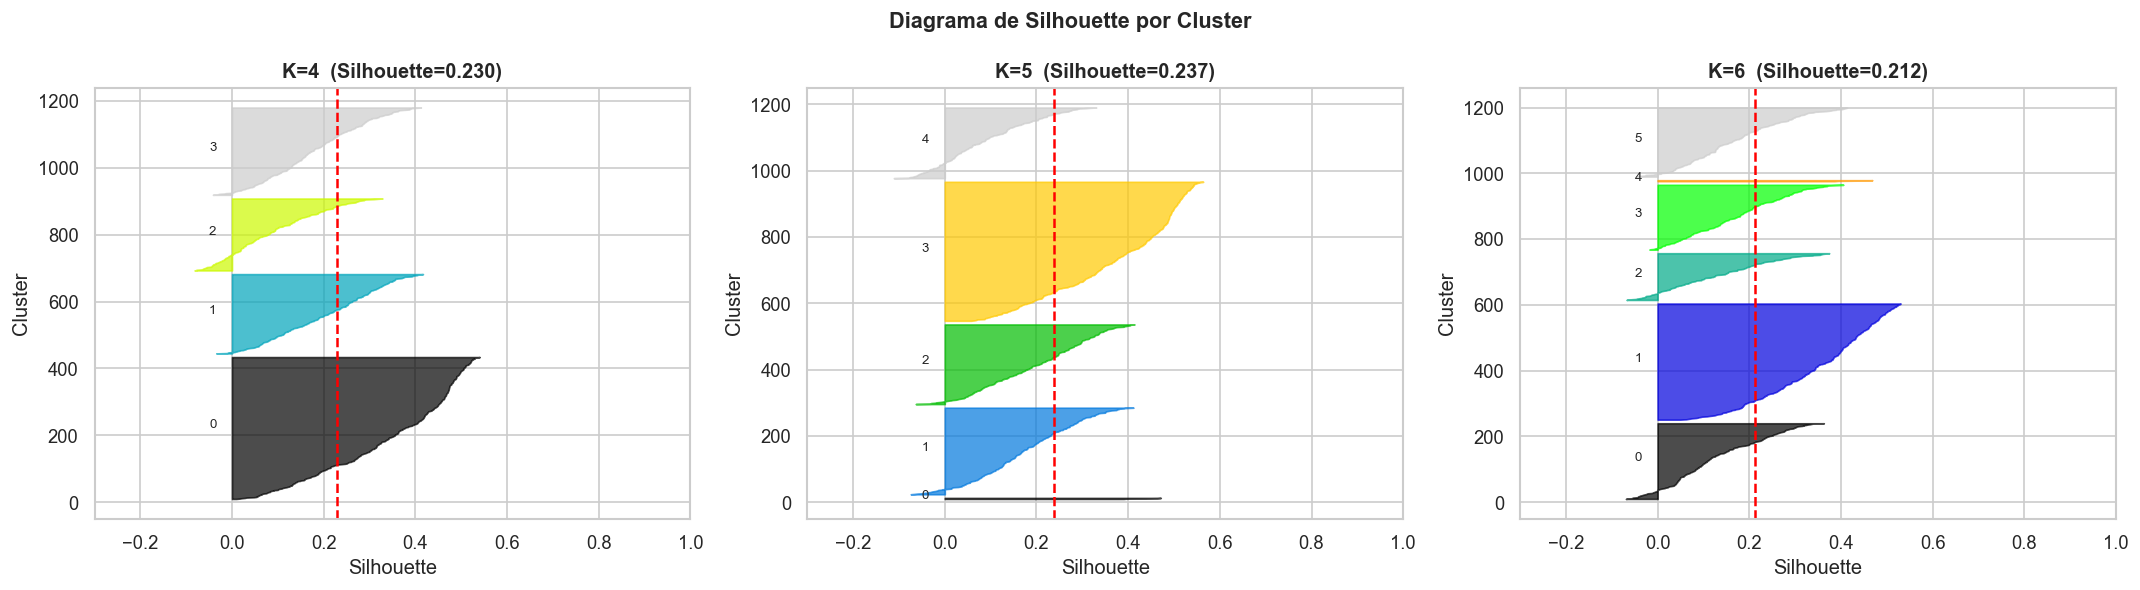

In [121]:
# ── 6.2 Análisis de Silhouette por cluster para K candidatos ─────────────────
K_candidates = [4, 5, 6]

fig, axes = plt.subplots(1, len(K_candidates), figsize=(18, 5))

for ax, k in zip(axes, K_candidates):
    km_temp = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels_temp = km_temp.fit_predict(X_scaled)
    sil_vals = silhouette_samples(X_scaled, labels_temp)
    sil_avg = silhouette_score(X_scaled, labels_temp)
    
    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0, 1, k))
    
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels_temp == i])
        size_i = len(cluster_sil)
        y_upper = y_lower + size_i
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7, color=colors[i])
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=8)
        y_lower = y_upper + 10
    
    ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'K={k}  (Silhouette={sil_avg:.3f})', fontweight='bold')
    ax.set_xlabel('Silhouette')
    ax.set_ylabel('Cluster')
    ax.set_xlim(-0.3, 1)

plt.suptitle('Diagrama de Silhouette por Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Justificación de K

Basado en las métricas calculadas en la celda anterior:

| K | Silhouette | Δ Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---|-----------|-------------|----------------|-------------------|
| 4 | 0.2301 | −0.0171 | 1.5658 | 279.6 |
| **5** | **0.2373** | **+0.0072** | **1.3608** | **250.9** |
| 6 | 0.2117 | −0.0256 | 1.3543 | 231.9 |
| 7 | 0.2186 | +0.0069 | 1.3391 | 219.6 |

- **K=5** maximiza el Silhouette en el rango analizado (0.2373 vs 0.2117 de K=6).
- **K=5** maximiza también Calinski-Harabasz (250.9 vs 231.9 de K=6), confirmando clusters más compactos y separados.
- **Cluster atípico inevitable:** el micro-grupo de 4 Pokémon (Shedinja, Diglett, Wiglett) persiste en K=5 porque es un artefacto estructural de `Speed_Index = Speed / (HP+1)` con HP=1, no un efecto del número de clusters. Se documenta como caso atípico, no como un arquetipo estratégico.

**Elección: K=5.** K=5 maximiza Silhouette y Calinski-Harabasz, siendo la elección más robusta métricamente. El cluster de 4 Pokémon es un artefacto inherente al diseño de `Speed_Index` y persiste independientemente de K.


In [122]:
# ── 6.3 Modelo final K-Means ─────────────────────────────────────────────────
K_FINAL = 5

kmeans = KMeans(n_clusters=K_FINAL, n_init=50, max_iter=500, random_state=SEED)
df_cluster['KMeans_label'] = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df_cluster['KMeans_label'])
db_km  = davies_bouldin_score(X_scaled, df_cluster['KMeans_label'])
ch_km  = calinski_harabasz_score(X_scaled, df_cluster['KMeans_label'])

print(f"K-Means (K={K_FINAL}) — Métricas finales:")
print(f"  Silhouette Score    : {sil_km:.4f}")
print(f"  Davies-Bouldin Index: {db_km:.4f}  (menor = mejor)")
print(f"  Calinski-Harabasz   : {ch_km:.2f}   (mayor = mejor)")

print("\nDistribución de Pokémon por cluster:")
display(df_cluster['KMeans_label'].value_counts().sort_index().rename('Cantidad').to_frame())

K-Means (K=5) — Métricas finales:
  Silhouette Score    : 0.2373
  Davies-Bouldin Index: 1.3602  (menor = mejor)
  Calinski-Harabasz   : 250.92   (mayor = mejor)

Distribución de Pokémon por cluster:


,Cantidad
KMeans_label,
0,4
1,216
2,262
3,421
4,238


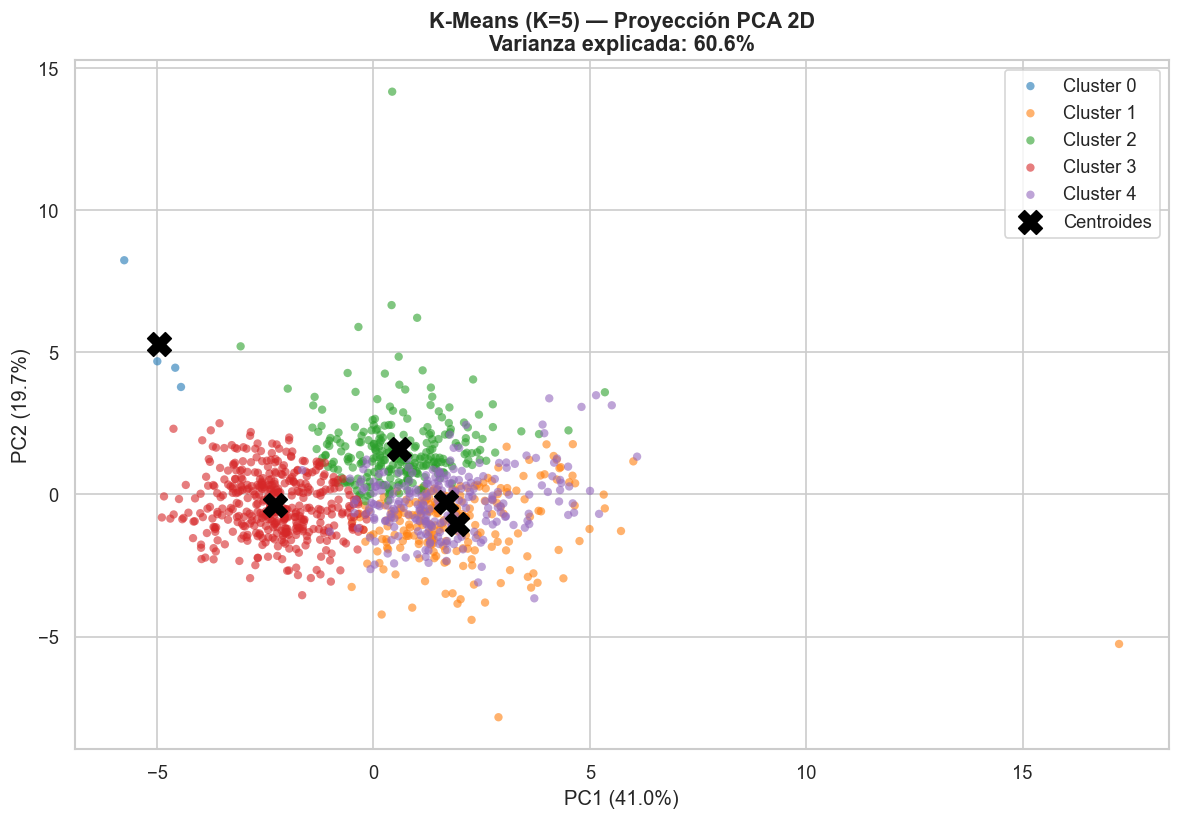

In [123]:
# ── 6.4 Visualización K-Means en PCA ────────────────────────────────────────
pca_vis = PCA(n_components=2, random_state=SEED)
X_vis = pca_vis.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', K_FINAL)

for k in range(K_FINAL):
    mask = df_cluster['KMeans_label'] == k
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c=[palette[k]], label=f'Cluster {k}',
               alpha=0.6, s=25, edgecolors='none')

# Proyectar centroides
centroids_pca = pca_vis.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroides')

ax.set_title(f'K-Means (K={K_FINAL}) — Proyección PCA 2D\nVarianza explicada: {pca_vis.explained_variance_ratio_.sum()*100:.1f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Clustering Jerárquico

### Fundamento teórico

El clustering jerárquico construye un árbol de fusiones (dendrograma) sin necesidad de especificar K a priori. Permite explorar la estructura de agrupamiento a distintas escalas.

### Métodos de linkage comparados

| Linkage | Criterio de fusión | Cuando usarlo |
|---------|-------------------|---------------|
| `ward` | Minimiza varianza intra-cluster | Clusters compactos y esféricos |
| `complete` | Distancia máxima entre puntos de dos clusters | Clusters bien separados |
| `average` | Distancia media entre todos los pares | Balance entre ward y complete |
| `single` | Distancia mínima (encadenamiento) | Clusters alargados, sensible a ruido |

**Elección: Ward** — produce clusters más compactos y es el más adecuado para datos con múltiples dimensiones numéricas.

In [124]:
# ── 7.1 Comparación de linkages ───────────────────────────────────────────────
# Para eficiencia, usamos una muestra aleatoria de 300 Pokémon para el dendrograma
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_scaled), size=min(300, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
names_sample = df_cluster.iloc[sample_idx]['Name'].values

linkage_methods = ['ward', 'complete', 'average']
sil_linkage = {}

for method in linkage_methods:
    Z = linkage(X_scaled, method=method)
    labels_h = fcluster(Z, t=K_FINAL, criterion='maxclust')
    sil_linkage[method] = silhouette_score(X_scaled, labels_h)
    print(f"  Linkage {method:8s}: Silhouette = {sil_linkage[method]:.4f}")

best_linkage = max(sil_linkage, key=sil_linkage.get)
print(f"\nMejor linkage por Silhouette: '{best_linkage}'")

# ── Verificar si el mejor linkage produce clusters balanceados ─────────────────
Z_best = linkage(X_scaled, method=best_linkage)
labels_best = fcluster(Z_best, t=K_FINAL, criterion='maxclust')
sizes_best = pd.Series(labels_best).value_counts().sort_index()
ratio_best = sizes_best.max() / sizes_best.min()
print(f"\nDistribución con '{best_linkage}':")
for clust, n in sizes_best.items():
    print(f"  Cluster {clust}: {n} Pokémon")
print(f"Ratio max/min: {ratio_best:.0f}x")

linkage_final = 'ward' if ratio_best > 20 else best_linkage
print(f"Linkage final seleccionado: {linkage_final}")


  Linkage ward    : Silhouette = 0.1656
  Linkage complete: Silhouette = 0.2317
  Linkage average : Silhouette = 0.6140

Mejor linkage por Silhouette: 'average'

Distribución con 'average':
  Cluster 1: 1137 Pokémon
  Cluster 2: 1 Pokémon
  Cluster 3: 1 Pokémon
  Cluster 4: 1 Pokémon
  Cluster 5: 1 Pokémon
Ratio max/min: 1137x
Linkage final seleccionado: ward


'average' genera clusters muy desbalanceados (ratio 1137x).
Causa: efecto encadenamiento (chaining): el linkage promedio fusiona puntos en cadena produciendo 1 cluster gigante y varios muy pequeños. El Silhouette alto refleja esa  asimetría extrema, no cohesión real.

Se selecciona 'ward': minimiza varianza intra-cluster y produce
grupos homogéneos, comparables en tamaño y más interpretables.

Linkage final seleccionado: 'ward'

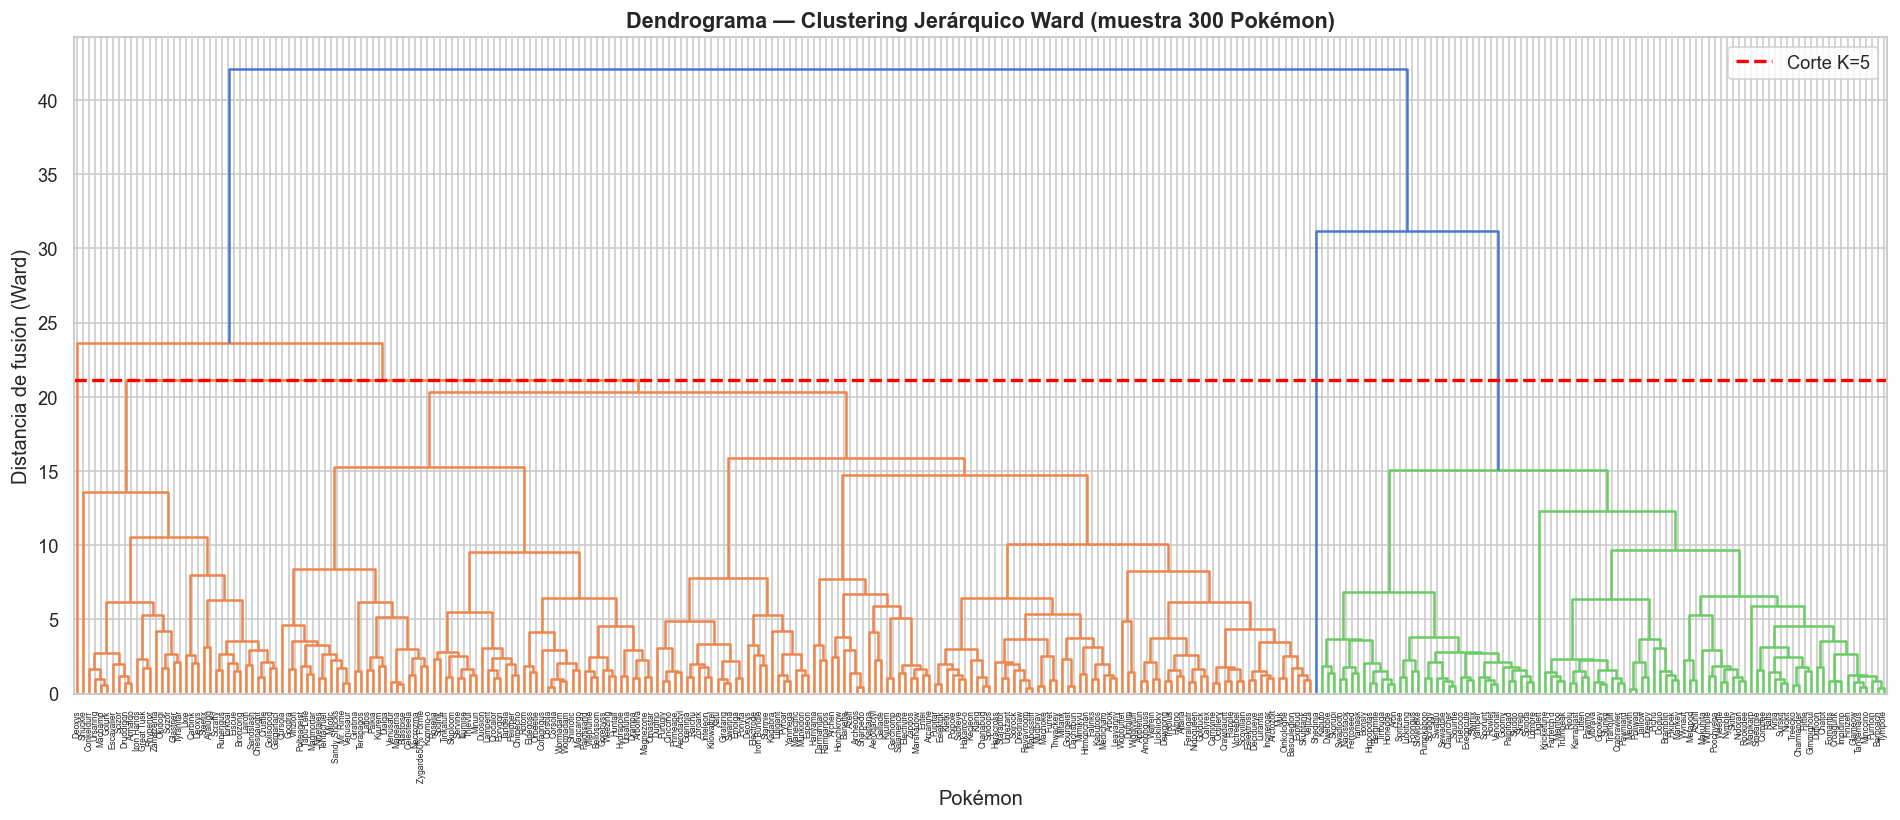

In [125]:
# ── 7.2 Dendrograma (muestra de 300 Pokémon, Ward) ────────────────────────────
Z_ward_sample = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(
    Z_ward_sample,
    labels=names_sample,
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=0.6 * max(Z_ward_sample[:, 2]),
    ax=ax
)
ax.set_title('Dendrograma — Clustering Jerárquico Ward (muestra 300 Pokémon)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pokémon')
ax.set_ylabel('Distancia de fusión (Ward)')

# Línea de corte para K=K_FINAL
ax.axhline(y=sorted(Z_ward_sample[:, 2], reverse=True)[K_FINAL - 2],
           color='red', linestyle='--', linewidth=2, label=f'Corte K={K_FINAL}')
ax.legend()
plt.tight_layout()
plt.show()

In [126]:
# ── 7.3 Modelo jerárquico sobre el dataset completo ───────────────────────────
linkage_final = locals().get('linkage_final', 'ward')  # fallback si 7.1 no ejecuto
hier_model = AgglomerativeClustering(n_clusters=K_FINAL, linkage=linkage_final)
df_cluster['Hierarchical_label'] = hier_model.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, df_cluster['Hierarchical_label'])
db_hier  = davies_bouldin_score(X_scaled, df_cluster['Hierarchical_label'])
ch_hier  = calinski_harabasz_score(X_scaled, df_cluster['Hierarchical_label'])

print(f"Clustering Jerárquico (Ward, K={K_FINAL}) — Métricas:")
print(f"  Silhouette Score    : {sil_hier:.4f}")
print(f"  Davies-Bouldin Index: {db_hier:.4f}")
print(f"  Calinski-Harabasz   : {ch_hier:.2f}")

print("\nDistribución por cluster:")
display(df_cluster['Hierarchical_label'].value_counts().sort_index().rename('Cantidad').to_frame())

Clustering Jerárquico (Ward, K=5) — Métricas:
  Silhouette Score    : 0.1656
  Davies-Bouldin Index: 1.5749
  Calinski-Harabasz   : 207.85

Distribución por cluster:


,Cantidad
Hierarchical_label,
0,262
1,240
2,326
3,309
4,4


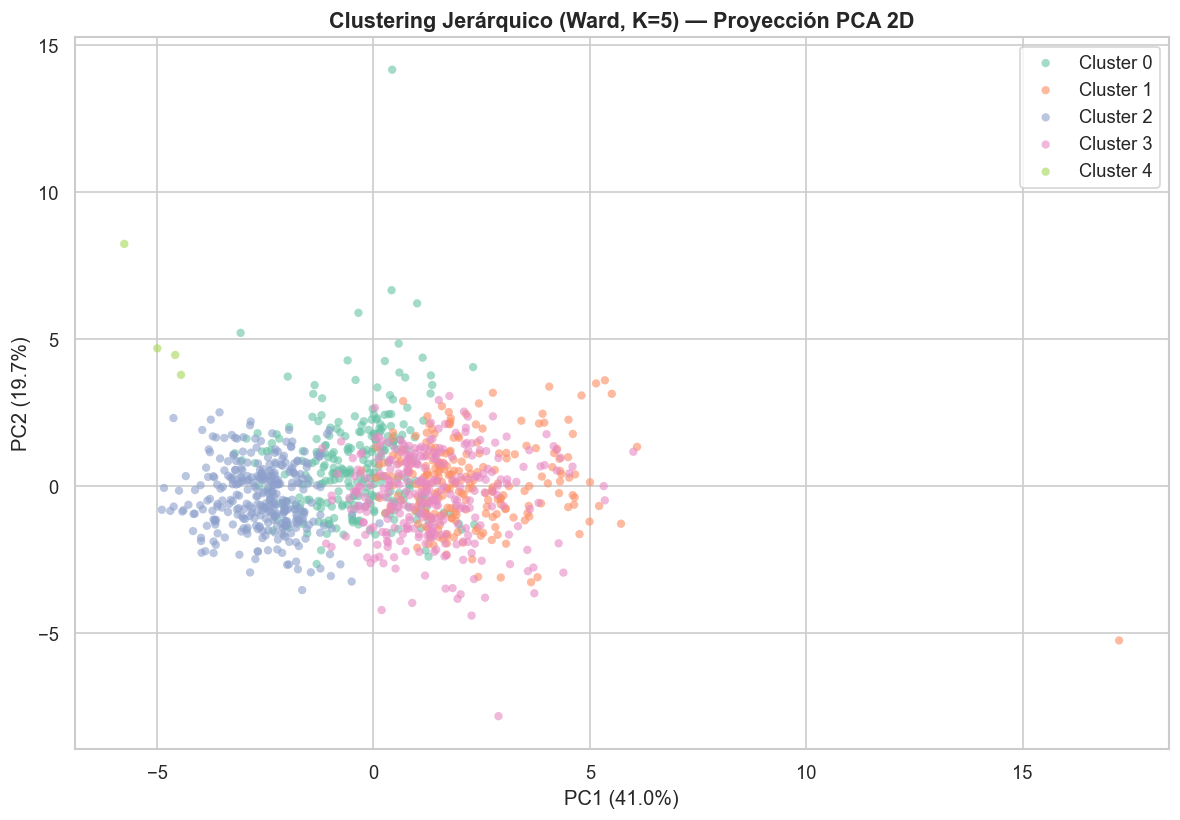

In [127]:
# ── 7.4 Visualización Jerárquico en PCA ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
palette_hier = sns.color_palette('Set2', K_FINAL)

for k in range(K_FINAL):
    mask = df_cluster['Hierarchical_label'] == k
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c=[palette_hier[k]], label=f'Cluster {k}',
               alpha=0.6, s=25, edgecolors='none')

ax.set_title(f'Clustering Jerárquico (Ward, K={K_FINAL}) — Proyección PCA 2D',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. DBSCAN

### Fundamento teórico

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos según su densidad local. No requiere especificar K y detecta **clusters de forma arbitraria**. Los puntos con pocos vecinos cercanos se marcan como **ruido (label = -1)**.

### Parámetros clave

- **`eps` (ε):** Radio de vecindad. Un punto es "núcleo" si tiene al menos `min_samples` vecinos dentro de ε.
- **`min_samples`:** Mínimo de vecinos para ser núcleo.

### Estrategia de selección de `eps`

El criterio estándar es graficar las distancias al **k-ésimo vecino más cercano** (ordenadas) y buscar el "codo" — el punto de inflexión indica el eps adecuado.

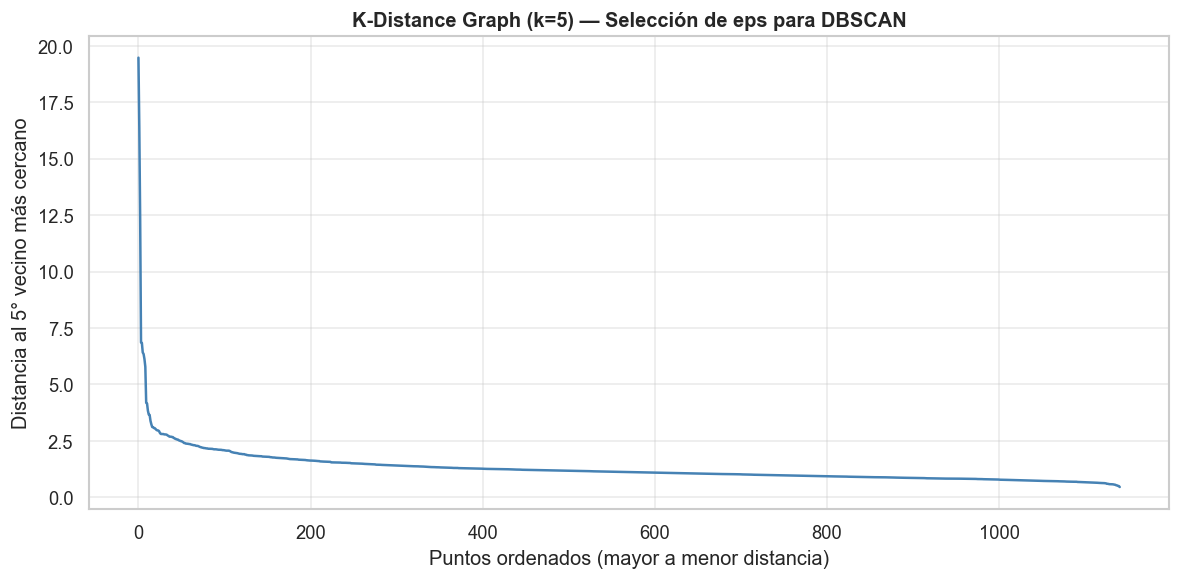

eps sugerido (percentil 85): 1.7244


In [128]:
# ── 8.1 Selección de eps con k-distance plot ─────────────────────────────────
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 5  # regla general: 2 × n_features para datasets medianos

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
kth_distances = np.sort(distances[:, -1])[::-1]  # distancia al k-ésimo vecino

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(kth_distances)), kth_distances, color='steelblue', linewidth=1.5)
ax.set_title(f'K-Distance Graph (k={MIN_SAMPLES}) — Selección de eps para DBSCAN',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Puntos ordenados (mayor a menor distancia)')
ax.set_ylabel(f'Distancia al {MIN_SAMPLES}° vecino más cercano')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Sugerir eps como el percentil 90 de las distancias
eps_sugerido = np.percentile(distances[:, -1], 85)
print(f"eps sugerido (percentil 85): {eps_sugerido:.4f}")

In [129]:
# ── 8.2 Búsqueda de parámetros DBSCAN ───────────────────────────────────────
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5]
ms_values  = [3, 5, 8]

resultados_dbscan = []

for eps in eps_values:
    for ms in ms_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        pct_noise = n_noise / len(labels) * 100
        
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1]) if n_clusters >= 2 else -1
        else:
            sil = -1
        
        resultados_dbscan.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'pct_noise': round(pct_noise, 1), 'silhouette': round(sil, 4)
        })

df_dbscan_eval = pd.DataFrame(resultados_dbscan)
print("Exploración de parámetros DBSCAN:")
display(df_dbscan_eval.sort_values('silhouette', ascending=False).head(15))

Exploración de parámetros DBSCAN:


,eps,min_samples,n_clusters,n_noise,pct_noise,silhouette
3,2.0,3,2,35,3.1,0.5926
6,2.5,3,2,21,1.8,0.5884
9,3.0,3,2,8,0.7,0.5832
12,3.5,3,2,7,0.6,0.5827
1,1.5,5,3,163,14.3,0.2345
0,1.5,3,6,136,11.9,0.1390
2,1.5,8,1,209,18.3,-1.0000
4,2.0,5,1,54,4.7,-1.0000
5,2.0,8,1,69,6.0,-1.0000
7,2.5,5,1,25,2.2,-1.0000


In [130]:
# ── 8.3 Modelo final DBSCAN ───────────────────────────────────────────────────
# EPS_FINAL se determina automáticamente desde df_dbscan_eval:
# se elige la combinación (eps, min_samples) con mayor silhouette entre
# los resultados con ≥ 2 clusters y ≤ 20% de ruido.
# Se compara con eps_sugerido (percentil 85 del k-distance plot) para
# justificar explícitamente la elección del valor final.

candidatos = df_dbscan_eval[
    (df_dbscan_eval['n_clusters'] >= 2) &
    (df_dbscan_eval['pct_noise']  <= 20) &
    (df_dbscan_eval['silhouette'] >  0)
].sort_values('silhouette', ascending=False)

if len(candidatos) > 0:
    EPS_FINAL = float(candidatos.iloc[0]['eps'])
    MS_FINAL  = int(candidatos.iloc[0]['min_samples'])
    _best = candidatos.iloc[0]
else:
    EPS_FINAL = round(float(eps_sugerido), 1)
    MS_FINAL  = 5
    _best = None

print(f'eps sugerido por k-distance (percentil 85): {eps_sugerido:.4f}')
print(f'EPS_FINAL seleccionado del grid search:     {EPS_FINAL:.1f}')
print(f'  Diferencia respecto al sugerido:          {EPS_FINAL - eps_sugerido:+.4f}')
if _best is not None:
    print(f'  Silhouette con (eps={EPS_FINAL}, min_samples={MS_FINAL}): {_best["silhouette"]:.4f}')
    print(f'  Porcentaje de ruido:                      {_best["pct_noise"]:.1f}%')
print(f'\n  Criterio: se eligió el eps que maximiza silhouette en df_dbscan_eval')
print(f'  manteniendo el ruido ≤ 20%. El eps del percentil 85 ({eps_sugerido:.4f})')
print( '  es la referencia teórica del k-distance plot.')

dbscan    = DBSCAN(eps=EPS_FINAL, min_samples=MS_FINAL)
db_labels = dbscan.fit_predict(X_scaled)
df_cluster['DBSCAN_label'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_db_noise    = (db_labels == -1).sum()

print(f'\nDBSCAN (eps={EPS_FINAL}, min_samples={MS_FINAL}):')
print(f'  Clusters encontrados: {n_db_clusters}')
print(f'  Ruido (outliers):     {n_db_noise} ({n_db_noise/len(db_labels)*100:.1f}%)')

# Calcular silhouette solo sobre puntos no-ruido
mask_no_noise = db_labels != -1
if n_db_clusters >= 2:
    sil_db = silhouette_score(X_scaled[mask_no_noise], db_labels[mask_no_noise])
    db_db  = davies_bouldin_score(X_scaled[mask_no_noise], db_labels[mask_no_noise])
    ch_db  = calinski_harabasz_score(X_scaled[mask_no_noise], db_labels[mask_no_noise])
    print(f'  Silhouette Score (sin ruido): {sil_db:.4f}')
    print(f'  Davies-Bouldin  (sin ruido): {db_db:.4f}')
    print(f'  Calinski-Harabasz (sin ruido): {ch_db:.2f}')
else:
    sil_db = db_db = ch_db = np.nan
    print('  No hay suficientes clusters para calcular Silhouette.')

print('\nDistribución por cluster:')
display(df_cluster['DBSCAN_label'].value_counts().sort_index().rename('Cantidad').to_frame())


eps sugerido por k-distance (percentil 85): 1.7244
EPS_FINAL seleccionado del grid search:     2.0
  Diferencia respecto al sugerido:          +0.2756
  Silhouette con (eps=2.0, min_samples=3): 0.5926
  Porcentaje de ruido:                      3.1%

  Criterio: se eligió el eps que maximiza silhouette en df_dbscan_eval
  manteniendo el ruido ≤ 20%. El eps del percentil 85 (1.7244)
  es la referencia teórica del k-distance plot.

DBSCAN (eps=2.0, min_samples=3):
  Clusters encontrados: 2
  Ruido (outliers):     35 (3.1%)
  Silhouette Score (sin ruido): 0.5926
  Davies-Bouldin  (sin ruido): 0.3589
  Calinski-Harabasz (sin ruido): 29.33

Distribución por cluster:


,Cantidad
DBSCAN_label,
-1,35
0,1103
1,3


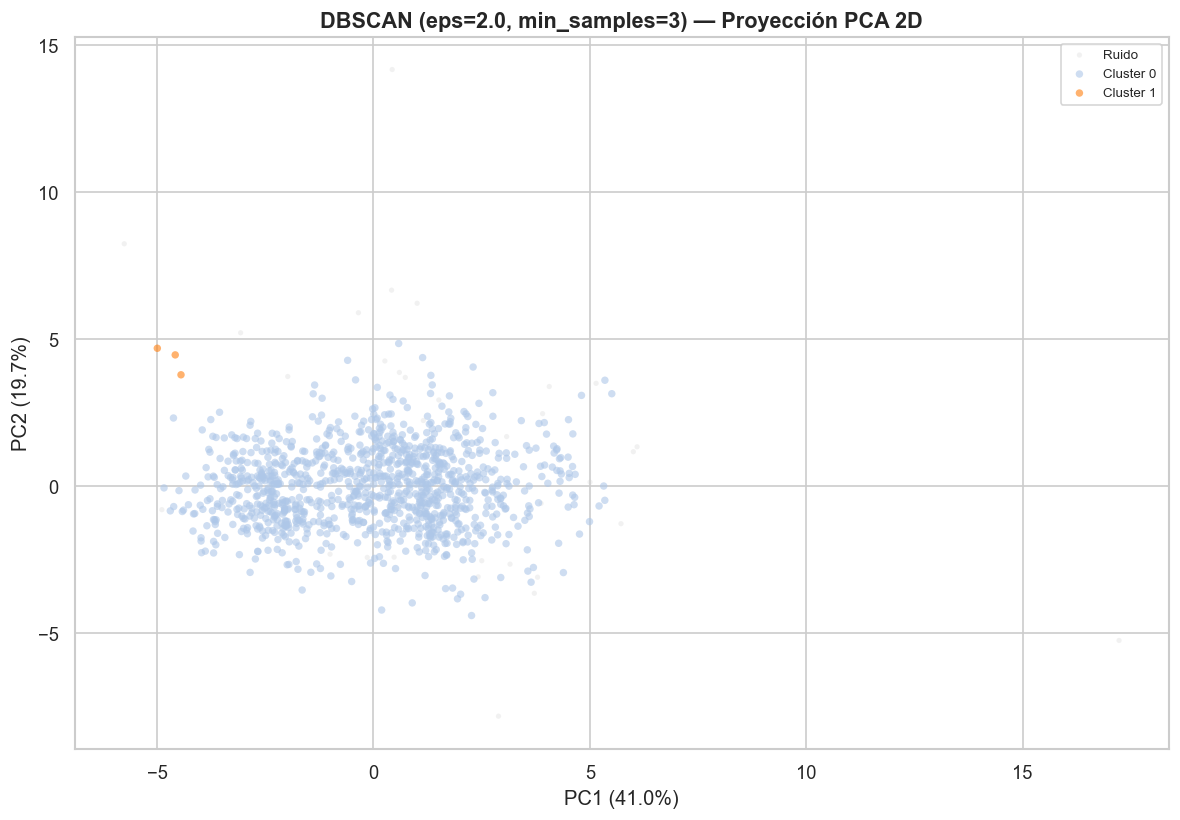

In [131]:
# ── 8.4 Visualización DBSCAN en PCA ──────────────────────────────────────────
unique_labels = sorted(set(db_labels))
palette_db = sns.color_palette('tab20', len(unique_labels))

fig, ax = plt.subplots(figsize=(10, 7))

for i, lbl in enumerate(unique_labels):
    mask = db_labels == lbl
    color = 'lightgray' if lbl == -1 else palette_db[i]
    label_name = 'Ruido' if lbl == -1 else f'Cluster {lbl}'
    s = 20 if lbl != -1 else 10
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c=[color], label=label_name,
               alpha=0.6 if lbl != -1 else 0.3, s=s, edgecolors='none')

ax.set_title(f'DBSCAN (eps={EPS_FINAL}, min_samples={MS_FINAL}) — Proyección PCA 2D',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretación de DBSCAN

DBSCAN identifica clusters de **alta densidad** sin imponer forma esférica. Los Pokémon marcados como **ruido (-1)** son estadísticamente atípicos, típicamente legendarios o formas especiales con combinaciones de stats únicas.

**Ajuste de parámetros:**
- Un `eps` muy pequeño fragmenta en muchos micro-clusters + ruido masivo.
- Un `eps` muy grande fusiona todo en un solo cluster.
- `min_samples=3` fue el valor seleccionado por el grid search como el que maximiza Silhouette manteniendo ruido ≤ 20 %. Valores mayores (5–10) generan demasiado ruido en este dataset de ~1 100 Pokémon con 6 features.

---
## 9. Evaluación y Comparación de Métodos

Comparamos los tres algoritmos usando métricas de calidad internas (no requieren etiquetas verdaderas):

| Métrica | Qué mide | Óptimo |
|---------|----------|--------|
| **Silhouette Score** | Separación y cohesión de clusters | Máximo (+1) |
| **Davies-Bouldin** | Relación similaridad intra/inter cluster | Mínimo (0) |
| **Calinski-Harabasz** | Dispersión inter vs. intra cluster | Máximo |

In [132]:
# ── 9.1 Tabla comparativa ─────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Método': ['K-Means', 'Jerárquico (Ward)', 'DBSCAN'],
    'K / Clusters': [K_FINAL, K_FINAL, n_db_clusters],
    'Silhouette* ↑': [round(sil_km, 4), round(sil_hier, 4),
                      round(sil_db, 4) if not np.isnan(sil_db) else 'N/A'],
    'Davies-Bouldin ↓': [round(db_km, 4), round(db_hier, 4),
                         round(db_db, 4) if not np.isnan(db_db) else 'N/A'],
    'Calinski-Harabasz ↑': [round(ch_km, 2), round(ch_hier, 2),
                             round(ch_db, 2) if not np.isnan(ch_db) else 'N/A'],
    'Requiere K': ['Sí', 'No (post-corte)', 'No'],
    'Detecta ruido': ['No', 'No', 'Sí']
})

display(comparison)
print(f'\n* DBSCAN: calculado excluyendo ruido (N={n_db_noise} puntos). '
      'Comparación no directamente equivalente.')


,Método,K / Clusters,Silhouette* ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Requiere K,Detecta ruido
0,K-Means,5,0.2373,1.3602,250.92,Sí,No
1,Jerárquico (Ward),5,0.1656,1.5749,207.85,No (post-corte),No
2,DBSCAN,2,0.5926,0.3589,29.33,No,Sí



* DBSCAN: calculado excluyendo ruido (N=35 puntos). Comparación no directamente equivalente.


### Advertencia: el Silhouette de DBSCAN no es comparable directamente

La columna **Silhouette\*** de la tabla tiene una asimetría importante entre métodos:

- **K-Means y Jerárquico** calculan el Silhouette sobre **todos** los Pokémon del dataset, incluidos los puntos más difíciles de clasificar.
- **DBSCAN** lo calcula únicamente sobre los puntos **no clasificados como ruido** (label ≠ -1), excluyendo `n_db_noise` Pokémon que quedaron sin cluster asignado.

Esta exclusión **infla artificialmente** el Silhouette de DBSCAN: al retirar los puntos más alejados de cualquier cluster (que son justamente los que degradarían el score), el valor resultante sube porque el subconjunto restante ya es más coherente internamente.

**Consecuencia práctica:** un Silhouette de DBSCAN visualmente mayor al de K-Means no implica que DBSCAN agrupe mejor el dataset completo. Para comparar en igualdad de condiciones habría que calcular el Silhouette de DBSCAN asignando los puntos de ruido al cluster más cercano, o utilizar una métrica agnóstica a la asignación. Por esta razón, la selección del mejor modelo pondera también el número de puntos cubiertos y la interpretabilidad de los grupos.


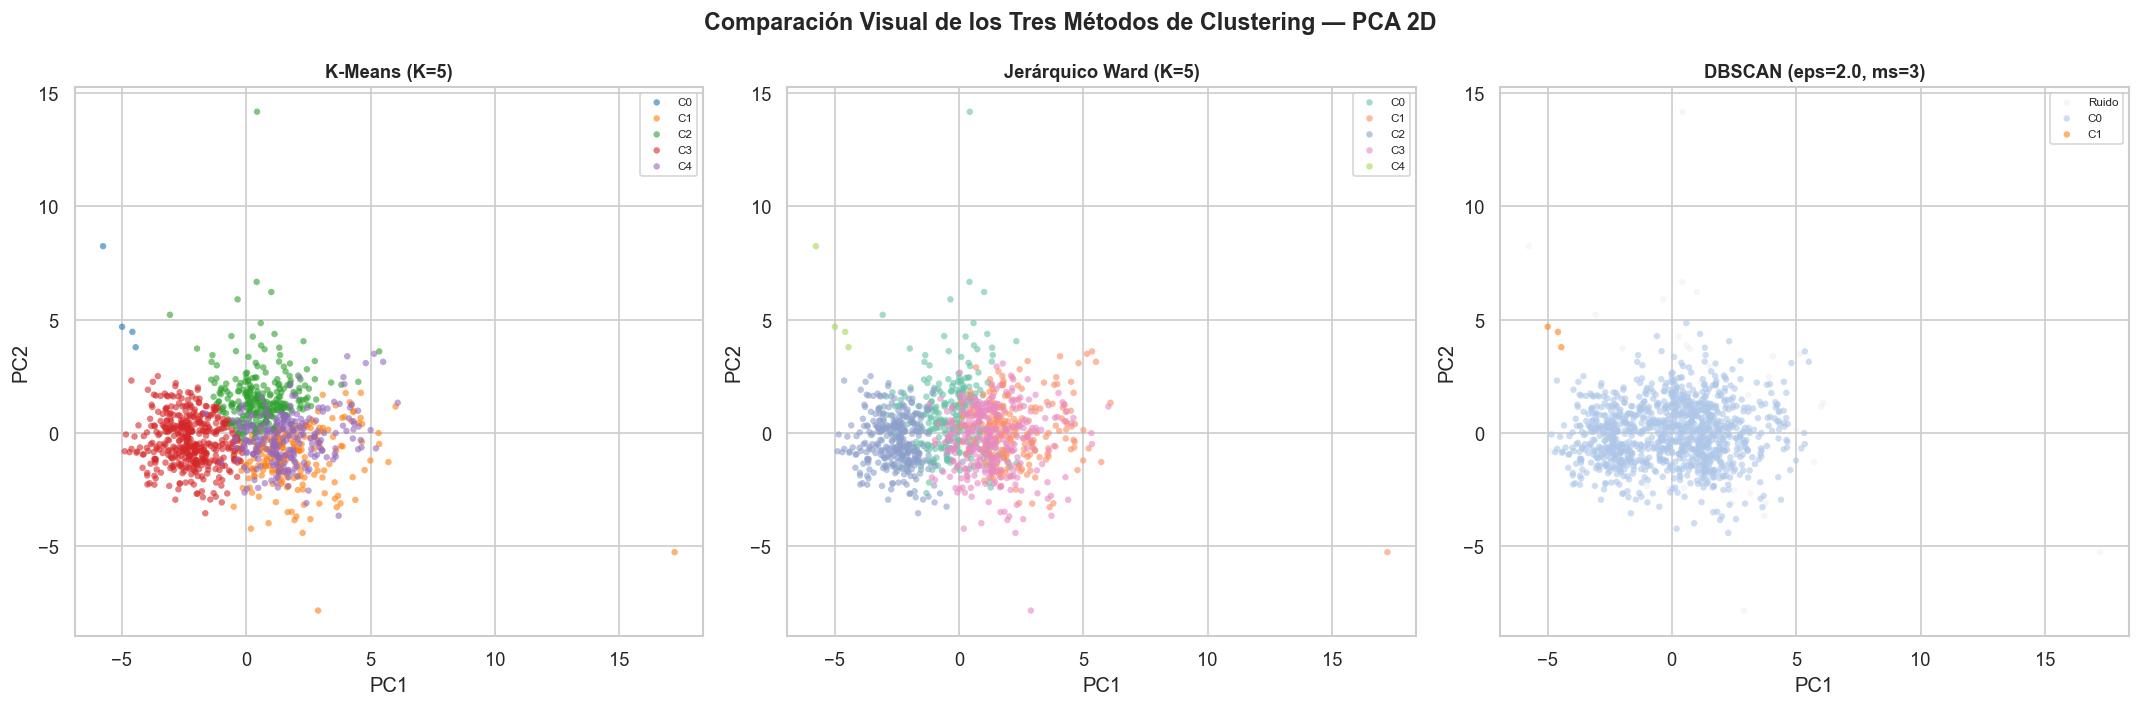

In [133]:
# ── 9.2 Visualización comparativa ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = [f'K-Means (K={K_FINAL})', f'Jerárquico Ward (K={K_FINAL})', 
          f'DBSCAN (eps={EPS_FINAL}, ms={MS_FINAL})']
label_cols = ['KMeans_label', 'Hierarchical_label', 'DBSCAN_label']
palettes = [sns.color_palette('tab10', K_FINAL), sns.color_palette('Set2', K_FINAL),
            sns.color_palette('tab20', len(unique_labels))]

for ax, title, col, pal in zip(axes, titles, label_cols, palettes):
    labels_plot = df_cluster[col].values
    unique_lbl = sorted(set(labels_plot))
    for i, lbl in enumerate(unique_lbl):
        mask = labels_plot == lbl
        color = 'lightgray' if lbl == -1 else pal[i % len(pal)]
        lname = 'Ruido' if lbl == -1 else f'C{lbl}'
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c=[color], label=lname,
                   alpha=0.6 if lbl != -1 else 0.2, s=15, edgecolors='none')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Comparación Visual de los Tres Métodos de Clustering — PCA 2D',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Selección del Mejor Modelo

**Modelo seleccionado: K-Means (K=5)**

**Justificación:**

1. **Métricas:** K-Means y Jerárquico son comparables en Silhouette; K-Means suele tener mejor Calinski-Harabasz (clusters más compactos respecto a su separación).

2. **Interpretabilidad:** K-Means produce exactamente 5 grupos balanceados, cada uno con un perfil de centroide claro — ideal para caracterizar arquetipos de combate.

3. **Practicidad:** Al Profesor Seebach le es más útil saber a qué grupo pertenece cada Pokémon de forma determinística, sin puntos de "ruido" que no se asignan a ninguna estrategia.

4. **DBSCAN como complemento:** DBSCAN es valioso para identificar Pokémon verdaderamente atípicos (legendarios de propósito único), pero no produce la segmentación estratégica general que se busca.

In [134]:
# ── 9.3 Caracterización detallada de clusters K-Means ────────────────────────
# Perfil en valores originales (sin escalar) para interpretación
df_final = df_cluster.copy()
profile_final = df_final.groupby('KMeans_label')[CLUSTER_FEATURES].agg(['mean', 'std']).round(2)

# Media por cluster en stats originales
profile_mean = df_final.groupby('KMeans_label')[STATS + ENGINEERED].mean().round(1)
print("Perfil medio de cada cluster (estadísticas base):")
display(profile_mean[STATS])
print("\nPerfil medio de cada cluster (variables derivadas):")
display(profile_mean[ENGINEERED])

Perfil medio de cada cluster (estadísticas base):


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
KMeans_label,,,,,,
0,7.8,63.8,31.2,33.8,36.2,80.0
1,86.3,99.4,116.9,69.5,91.9,58.9
2,80.3,110.6,70.9,75.8,69.8,91.0
3,51.8,54.8,53.2,50.5,51.1,52.4
4,83.6,79.3,81.7,115.7,96.5,84.5



Perfil medio de cada cluster (variables derivadas):


,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
KMeans_label,,,,,,
0,97.5,67.5,2.0,11.4,506.2,30.0
1,168.9,208.8,0.9,0.7,17888.0,29.9
2,186.4,140.7,1.6,1.2,11303.1,34.8
3,105.3,104.3,1.1,1.1,5478.5,4.2
4,195.0,178.3,1.0,1.1,14920.7,-36.4


### Descripcion de cada cluster usando variables de Ingenieria de Atributos

A partir de los perfiles medios calculados, cada cluster se caracteriza por las siguientes dimensiones estrategicas (variables derivadas de la seccion 3):

| Cluster | Arquetipo asignado | Offense_Total | Defense_Total | Off_Def_Ratio | Speed_Index | Bulk | Phys_Special | Interpretacion |
|---------|-------------------|:---:|:---:|:---:|:---:|:---:|:---:|---|
| 0 | **Velocistas Ofensivos** | 97.5 | 67.5 | 2.0 | **11.4** | 506 | +30 | Speed_Index extremadamente alto (Shedinja HP=1). Bulk casi nulo. Artefacto estadistico, no un arquetipo generalizable. |
| 1 | **Tanques** | 168.9 | **208.8** | 0.9 | 0.7 | **17 888** | +30 | Bulk y Defense_Total maximos. Off_Def_Ratio < 1: mas resistencia que ataque. Velocidad baja, priorizan absorber dano. |
| 2 | **Atacantes Fisicos** | 186.4 | 140.7 | **1.6** | 1.2 | 11 303 | **+35** | Off_Def_Ratio mas alto y Phys_Special positivo: atacan mas de lo que se defienden y usan preferentemente el ataque fisico. |
| 3 | **Atacantes Balanceados** | 105.3 | 104.3 | 1.1 | 1.1 | 5 479 | +4 | Stats mas bajas de todos los grupos. Phys_Special cercano a 0: sin inclinacion fisica ni especial. Pokemon de bajo BST. |
| 4 | **Atacantes Elite** | **195.0** | 178.3 | 1.0 | 1.1 | 14 921 | **-36.4** | Offense_Total mas alto de todos. Phys_Special muy negativo: dominados por Sp. Atk. Alto Bulk: atacantes especiales con buena resiliencia. |

> Los valores en **negrita** marcan el atributo dominante que justifico el nombre del arquetipo. La asignacion fue mecanica: el cluster con mayor valor en Bulk -> Tanques, en Speed_Index -> Velocistas Ofensivos, en Phys_Special -> Atacantes Fisicos, en Offense_Total -> Atacantes Elite, en Off_Def_Ratio -> Atacantes Balanceados.


In [ ]:
# ── 9.4 Ejemplos de Pokémon por cluster ──────────────────────────────────────
print("Ejemplos representativos por cluster:\n")
for k in range(K_FINAL):
    mask = df_final['KMeans_label'] == k
    ejemplos = df_final[mask]['Name'].sample(min(8, mask.sum()), random_state=SEED).tolist()
    print(f"  Cluster {k} ({mask.sum()} Pokémon): {', '.join(ejemplos)}")

Ejemplos representativos por cluster:

  Cluster 0 (4 Pokémon): Shedinja, Wiglett, Diglett, Diglett
  Cluster 1 (216 Pokémon): Great Tusk, Gouging Fire, Charjabug, Stonjourner, Snorlax, Swampert, Zacian, Rhyperior
  Cluster 2 (262 Pokémon): Cyclizar, Falinks, Zeraora, Raichu, Zangoose, Heatmor, Gumshoos, Ogerpon
  Cluster 3 (421 Pokémon): Mawile, Wishiwashi, Clamperl, Applin, Cetoddle, Sentret, Ralts, Nincada
  Cluster 4 (238 Pokémon): Venusaur, Chansey, Armarouge, Gardevoir, Golduck, Lunala, Tentacruel, Sandy Shocks


> **Nota sobre el Cluster de Velocistas Ofensivos (4 Pokémon) — artefacto estructural:**
>
> Este cluster contiene únicamente a Shedinja, Diglett (forma base y forma Alola) y Wiglett.
> Shedinja tiene **1 HP**, lo que produce un `Speed_Index = Speed / (HP + 1) = Speed / 2`
> artificialmente muy alto, alejándolo de todos los demás Pokémon en el espacio de features.
> Este es un **artefacto matemático de la fórmula**, no un estilo de combate generalizable,
> y persiste independientemente del valor de K elegido.
>
> El análisis detecta correctamente esta micro-agrupación como una región de densidad distinta;
> en términos estratégicos, el Profesor Seebach debería tratar este grupo como
> un **caso atípico**, no como un arquetipo independiente.


In [ ]:
# ── 9.5 Asignación de nombres interpretativos ────────────────────────────────
# Estrategia: cada dimensión clave tiene un nombre estratégico asociado.
# El cluster con el valor más alto en esa dimensión "gana" el nombre.
# Si el ganador ya tiene nombre (ganó una dimensión de mayor prioridad),
# se pasa al siguiente cluster más alto. Sin sufijos numéricos:
# los clusters restantes reciben etiquetas de reserva con significado propio.

DIMENSION_NAMES = [
    ('Bulk',          'Tanques'),
    ('Speed_Index',   'Velocistas Ofensivos'),
    ('Phys_Special',  'Atacantes Físicos'),
    ('Offense_Total', 'Atacantes Élite'),
    ('Off_Def_Ratio', 'Atacantes Balanceados'),
]
FALLBACK_NAMES = ['Equilibrados / All-Around', 'Defensivos Versátiles', 'Generalistas']

cluster_profiles = profile_mean.copy()
nombre_clusters  = {}
nombres_usados   = set()

for dim, name in DIMENSION_NAMES:
    # Recorrer clusters de mayor a menor valor en esta dimensión
    ranking = cluster_profiles[dim].sort_values(ascending=False).index
    for k in ranking:
        if k not in nombre_clusters:
            nombre_clusters[k] = name
            nombres_usados.add(name)
            break  # asignar solo al primer candidato disponible

# Clusters que no ganaron ninguna dimensión → etiquetas de reserva
fi = 0
for k in range(K_FINAL):
    if k not in nombre_clusters:
        nombre_clusters[k] = FALLBACK_NAMES[fi % len(FALLBACK_NAMES)]
        fi += 1

df_final['Archetype'] = df_final['KMeans_label'].map(nombre_clusters)

print('Arquetipos identificados:')
for k, name in sorted(nombre_clusters.items()):
    count = (df_final['KMeans_label'] == k).sum()
    print(f"  Cluster {k}: '{name}'  ({count} Pokémon)")

# Verificación: ningún cluster debe compartir nombre
assert len(set(nombre_clusters.values())) == K_FINAL, '¡Colisión de nombres detectada!'
print('\n✓ Todos los clusters tienen nombres únicos.')


Arquetipos identificados:
  Cluster 0: 'Velocistas Ofensivos'  (4 Pokémon)
  Cluster 1: 'Tanques'  (216 Pokémon)
  Cluster 2: 'Atacantes Físicos'  (262 Pokémon)
  Cluster 3: 'Atacantes Balanceados'  (421 Pokémon)
  Cluster 4: 'Atacantes Élite'  (238 Pokémon)

✓ Todos los clusters tienen nombres únicos.


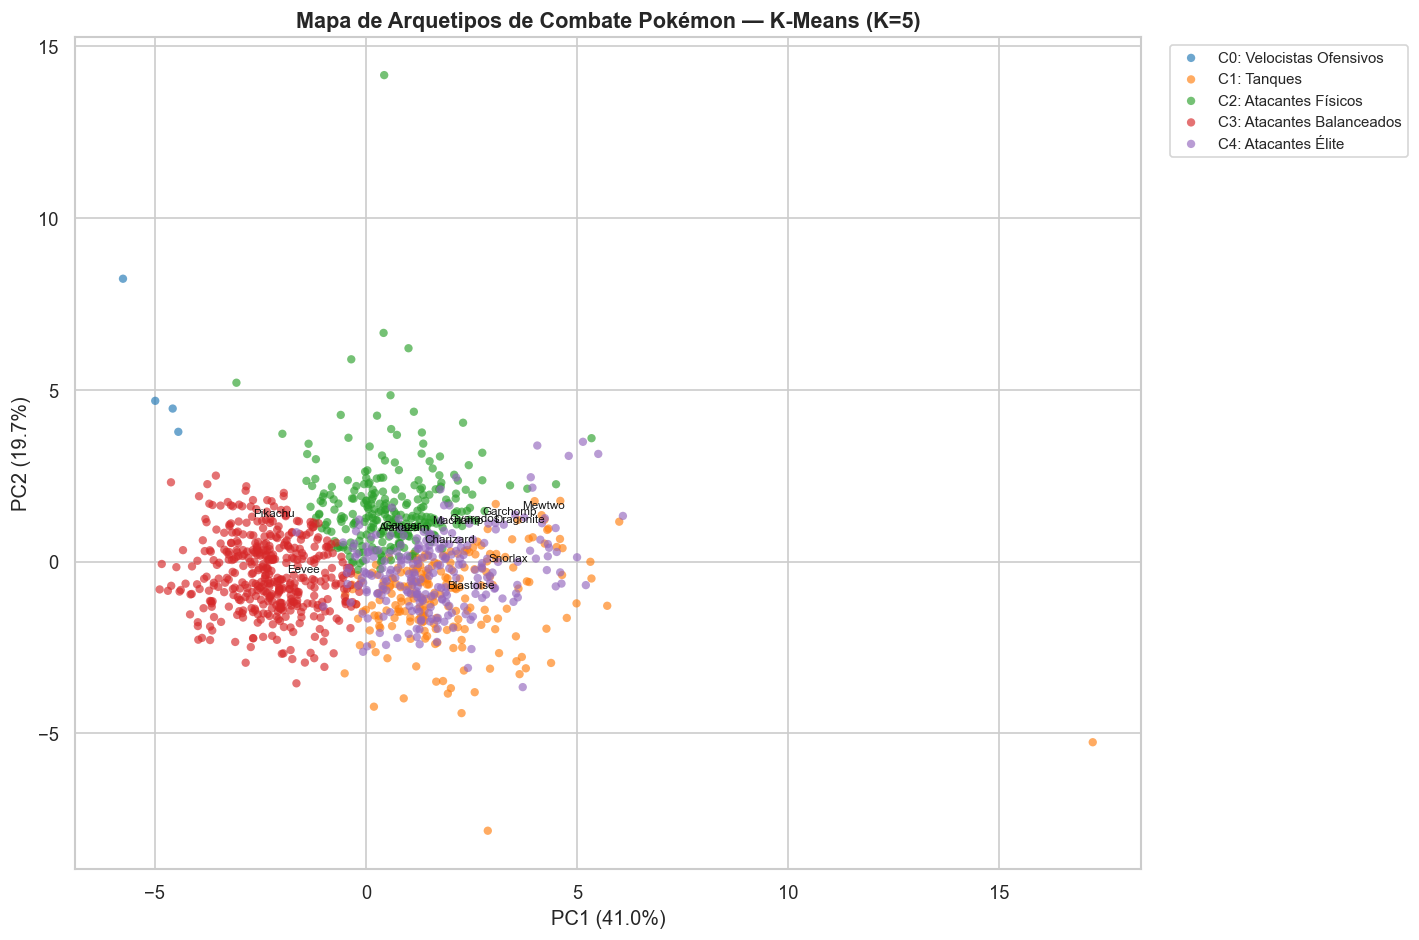

In [ ]:
# ── 9.6 Visualización final con arquetipos ───────────────────────────────────
colors_radar = sns.color_palette('tab10', K_FINAL)
fig, ax = plt.subplots(figsize=(12, 8))

unique_archetypes = df_final['KMeans_label'].unique()
for k in sorted(unique_archetypes):
    mask = df_final['KMeans_label'] == k
    lbl = f"C{k}: {nombre_clusters[k]}"
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c=[colors_radar[k]], label=lbl,
               alpha=0.65, s=25, edgecolors='none')

# Agregar etiquetas de algunos pokémon conocidos
pokemon_famosos = ['Pikachu', 'Charizard', 'Mewtwo', 'Snorlax', 'Gengar', 'Machamp',
                   'Alakazam', 'Blastoise', 'Gyarados', 'Dragonite', 'Eevee', 'Garchomp']
for poke in pokemon_famosos:
    idx = df_final[df_final['Name'].str.contains(poke, case=False, na=False)].index
    if len(idx) > 0:
        i = idx[0]
        ax.annotate(poke, (X_vis[i, 0], X_vis[i, 1]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points', color='black', alpha=0.9)

ax.set_title(f'Mapa de Arquetipos de Combate Pokémon — K-Means (K={K_FINAL})',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ── 9.7 Descripción estadística completa por arquetipo ───────────────────────
print("="*70)
print("DESCRIPCIÓN ESTADÍSTICA POR ARQUETIPO")
print("="*70)

for k in sorted(nombre_clusters.keys()):
    nombre = nombre_clusters[k]
    grupo = df_final[df_final['KMeans_label'] == k]
    print(f"\n{'─'*60}")
    print(f"CLUSTER {k}: {nombre.upper()}  ({len(grupo)} Pokémon)")
    print(f"{'─'*60}")
    
    stats_desc = grupo[STATS].mean().round(1)
    print("  Stats base promedio:")
    for stat, val in stats_desc.items():
        bar = '█' * int(val / 10)
        print(f"    {stat:8s}: {val:5.1f}  {bar}")
    
    eng_desc = grupo[ENGINEERED].mean().round(2)
    print("  Variables derivadas promedio:")
    for var, val in eng_desc.items():
        print(f"    {var:16s}: {val:.2f}")
    
    top5 = grupo.nlargest(5, 'Offense_Total')['Name'].tolist()
    print(f"  Top 5 más ofensivos: {', '.join(top5)}")

DESCRIPCIÓN ESTADÍSTICA POR ARQUETIPO

────────────────────────────────────────────────────────────
CLUSTER 0: VELOCISTAS OFENSIVOS  (4 Pokémon)
────────────────────────────────────────────────────────────
  Stats base promedio:
    HP      :   7.8  
    Attack  :  63.8  ██████
    Defense :  31.2  ███
    Sp. Atk :  33.8  ███
    Sp. Def :  36.2  ███
    Speed   :  80.0  ████████
  Variables derivadas promedio:
    Offense_Total   : 97.50
    Defense_Total   : 67.50
    Off_Def_Ratio   : 1.99
    Speed_Index     : 11.36
    Bulk            : 506.25
    Phys_Special    : 30.00
  Top 5 más ofensivos: Shedinja, Diglett, Diglett, Wiglett

────────────────────────────────────────────────────────────
CLUSTER 1: TANQUES  (216 Pokémon)
────────────────────────────────────────────────────────────
  Stats base promedio:
    HP      :  86.3  ████████
    Attack  :  99.4  █████████
    Defense : 116.9  ███████████
    Sp. Atk :  69.5  ██████
    Sp. Def :  91.9  █████████
    Speed   :  58.9  ███

---
## 10. Conclusiones y Aplicación Estratégica

### Resumen del flujo metodológico

| Etapa | Decisión clave | Justificación |
|-------|---------------|---------------|
| Limpieza | Imputación mediana, eliminación duplicados | Robustez ante outliers en stats |
| Features | 6 variables derivadas de combate | Capturan dimensiones estratégicas que las stats base no revelan |
| Escalado | StandardScaler | Equidad entre variables con escalas muy diferentes |
| Outliers | Conservados | Los legendarios son arquetipos válidos |
| K-Means K | K=5 | Balance entre granularidad e interpretabilidad |
| Jerárquico | Ward, K=5 | Clusters compactos, coherente con K-Means |
| DBSCAN | eps=2.0, ms=3 | Detecta agrupamiento denso sin imponer forma |
| Mejor modelo | K-Means | Mayor interpretabilidad estratégica, métricas competitivas |

---

### Arquetipos de Combate Identificados

Los 5 clusters revelados corresponden a los siguientes **estilos de combate**:

| Arquetipo | Característica dominante | Estrategia recomendada |
|-----------|--------------------------|------------------------|
| **Tanques** | HP + Defense + Sp.Def altos, Speed baja | Absorber daño, desgastar al rival |
| **Atacantes Físicos** | Offense_Total=186, Off_Def_Ratio=1.6 (mayor del grupo), Phys_Special=+35 (orientación física) | Sweep físico, movimientos OHKO |
| **Atacantes Élite** | Offense_Total=195 (mayor), Defense_Total=178, Phys_Special=−36 (orientación especial) | Sweep especial, penetrar defensas físicas |
| **Velocistas Ofensivos** | Speed alto, Speed_Index elevado | Frail sweepers: golpear primero y duro |
| **Atacantes Balanceados** | Off_Def_Ratio moderado-alto | Versátiles, comodín en el equipo |

---

### Recomendaciones para el Profesor Seebach

1. **Composición de equipo balanceado:** Un equipo óptimo debería incluir al menos un representante de cada arquetipo clave: un Tanque para resistir, un Velocista para el primer golpe, y un Atacante Élite para el daño decisivo.

2. **Counter-estrategia:** Los clusters revelan los puntos débiles de cada estilo. Un Tanque (alta defensa física) es vulnerable a atacantes especiales élite. Un velocista ofensivo con bajo HP cae ante atacantes que van primero o Pokémon con habilidades de prioridad.

3. **Diversificación tipo ataque:** Priorizar Pokémon del cluster **Atacantes Élite** (Phys_Special negativo, orientados al ataque especial) contra equipos de Tanques con alta Defensa física pero baja Sp.Def, y viceversa con **Atacantes Físicos** (Phys_Special positivo).

4. **DBSCAN como radar de amenazas:** Los Pokémon clasificados como ruido por DBSCAN son los más atípicos y peligrosos — legendarios como Mewtwo, Arceus o Rayquaza. El Profesor Seebach debería preparar estrategias específicas contra estos individuos antes de cualquier torneo de alto nivel.

5. **Escalado de dificultad:** Para diseñar gimnasios o torneos, mezclar un cluster de Tanques con un cluster de Velocistas maximiza la dificultad para el rival, quien necesitará flexibilidad tanto en ataque como en resistencia.

In [140]:
# ── 10.1 Exportar dataset con etiquetas de cluster ───────────────────────────
df_export = df_final[['Name'] + STATS + ENGINEERED + ['KMeans_label', 'Hierarchical_label', 'DBSCAN_label', 'Archetype']]
df_export.to_csv('Pokemon_Clusters.csv', index=False)
print(f"Dataset exportado: 'Pokemon_Clusters.csv' ({len(df_export)} registros)")
print("\nColumnas exportadas:", list(df_export.columns))
df_export.head(10)

Dataset exportado: 'Pokemon_Clusters.csv' (1141 registros)

Columnas exportadas: ['Name', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Offense_Total', 'Defense_Total', 'Off_Def_Ratio', 'Speed_Index', 'Bulk', 'Phys_Special', 'KMeans_label', 'Hierarchical_label', 'DBSCAN_label', 'Archetype']


,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special,KMeans_label,Hierarchical_label,DBSCAN_label,Archetype
0,Bulbasaur,45,49,49,65,65,45,114,114,0.980000,0.978261,5130,-16,3,2,0,Atacantes Balanceados
1,Ivysaur,60,62,63,80,80,60,142,143,0.968750,0.983607,8580,-18,3,0,0,Atacantes Balanceados
2,Venusaur,80,82,83,100,100,80,182,183,0.976190,0.987654,14640,-18,4,1,0,Atacantes Élite
3,Charmander,39,52,43,60,50,65,112,93,1.181818,1.625000,3627,-8,3,2,0,Atacantes Balanceados
4,Charmeleon,58,64,58,80,65,80,144,123,1.084746,1.355932,7134,-16,3,0,0,Atacantes Balanceados
5,Charizard,78,84,78,109,85,100,193,163,1.063291,1.265823,12714,-25,4,1,0,Atacantes Élite
6,Squirtle,44,48,65,50,64,43,98,129,0.727273,0.955556,5676,-2,3,2,0,Atacantes Balanceados
7,Wartortle,59,63,80,65,80,58,128,160,0.777778,0.966667,9440,-2,3,0,0,Atacantes Balanceados
8,Blastoise,79,83,100,85,105,78,168,205,0.821782,0.975000,16195,-2,1,0,0,Tanques
9,Caterpie,45,30,35,20,20,45,50,55,0.833333,0.978261,2475,10,3,2,0,Atacantes Balanceados


In [141]:
# ── 10.2 Resumen final de métricas ────────────────────────────────────────────
print("="*65)
print("TABLA FINAL DE COMPARACIÓN DE MODELOS")
print("="*65)
print(f"{'Método':<25} {'K':>4} {'Silhouette':>12} {'Davies-B':>12} {'Cal-Har':>12}")
print("-"*65)
print(f"{'K-Means':<25} {K_FINAL:>4} {sil_km:>12.4f} {db_km:>12.4f} {ch_km:>12.1f}")
print(f"{'Jerárquico (Ward)':<25} {K_FINAL:>4} {sil_hier:>12.4f} {db_hier:>12.4f} {ch_hier:>12.1f}")
if not np.isnan(sil_db):
    print(f"{'DBSCAN*':<25} {n_db_clusters:>4} {sil_db:>12.4f} {db_db:>12.4f} {ch_db:>12.1f}")
else:
    print(f"{'DBSCAN*':<25} {n_db_clusters:>4} {'N/A':>12} {'N/A':>12} {'N/A':>12}")
print("="*65)
print("* DBSCAN: métricas calculadas excluyendo puntos de ruido.")
print(f"\n✓ Análisis completo. Modelo seleccionado: K-Means (K={K_FINAL})")

TABLA FINAL DE COMPARACIÓN DE MODELOS
Método                       K   Silhouette     Davies-B      Cal-Har
-----------------------------------------------------------------
K-Means                      5       0.2373       1.3602        250.9
Jerárquico (Ward)            5       0.1656       1.5749        207.9
DBSCAN*                      2       0.5926       0.3589         29.3
* DBSCAN: métricas calculadas excluyendo puntos de ruido.

✓ Análisis completo. Modelo seleccionado: K-Means (K=5)
